load data
    id (unique identifier)
    label (truthfulness score). The classification task is binary, meaning that a claim can be either true or false.
    statement (text of the claim)
    subject (topic of the claim)
    speaker (person making the claim)
    speaker_job (occupation of the speaker)
    state_info (geographic context)
    party_affiliation (political party of the speaker)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")

In [2]:
# Load the training data
data_path = Path('../../data/train.csv')
df = pd.read_csv(data_path)

print(f"Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Data loaded successfully!
Shape: (8950, 8)

First few rows:


,id,label,statement,subject,speaker,speaker_job,state_info,party_affiliation
0,81f884c64a7,1,China is in the South China Sea and (building)...,"china,foreign-policy,military",donald-trump,President-Elect,New York,republican
1,30c2723a188,0,With the resources it takes to execute just ov...,health-care,chris-dodd,U.S. senator,Connecticut,democrat
2,6936b216e5d,0,The (Wisconsin) governor has proposed tax give...,"corporations,pundits,taxes,abc-news-week",donna-brazile,Political commentator,"Washington, D.C.",democrat
3,b5cd9195738,1,Says her representation of an ex-boyfriend who...,"candidates-biography,children,ethics,families,...",rebecca-bradley,NaN,NaN,none
4,84f8dac7737,0,At protests in Wisconsin against proposed coll...,"health-care,labor,state-budget",republican-party-wisconsin,NaN,Wisconsin,republican


In [3]:
# Data Info and Data Types
print("="*60)
print("DATA INFORMATION")
print("="*60)
print(f"\nData shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumn names and types:")
print(df.dtypes)
print(f"\nData Info:")
df.info()

DATA INFORMATION

Data shape: 8950 rows, 8 columns

Column names and types:
id                     str
label                int64
statement              str
subject                str
speaker                str
speaker_job            str
state_info             str
party_affiliation      str
dtype: object

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id                 8950 non-null   str  
 1   label              8950 non-null   int64
 2   statement          8950 non-null   str  
 3   subject            8950 non-null   str  
 4   speaker            8950 non-null   str  
 5   speaker_job        6468 non-null   str  
 6   state_info         7020 non-null   str  
 7   party_affiliation  8950 non-null   str  
dtypes: int64(1), str(7)
memory usage: 559.5 KB


In [4]:
# Missing Values Analysis
print("="*60)
print("MISSING VALUES ANALYSIS")
print("="*60)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percentage': missing_pct.values
})
print(missing_df[missing_df['Missing_Count'] > 0].to_string(index=False))
if missing_df['Missing_Count'].sum() == 0:
    print("✓ No missing values found!")

MISSING VALUES ANALYSIS
     Column  Missing_Count  Missing_Percentage
speaker_job           2482           27.731844
 state_info           1930           21.564246


TARGET VARIABLE DISTRIBUTION (Label)
Label 0: 3,155 samples (35.25%)
Label 1: 5,795 samples (64.75%)

Class Balance Ratio: 1.84:1


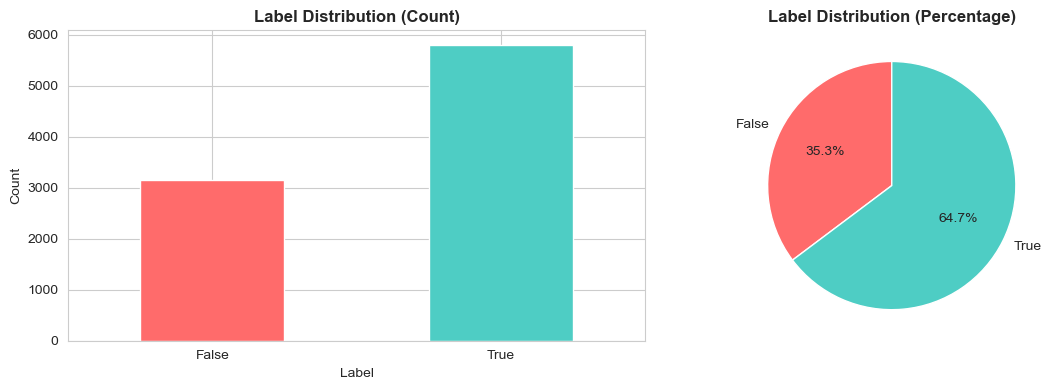

In [5]:
# Target Variable Analysis
print("="*60)
print("TARGET VARIABLE DISTRIBUTION (Label)")
print("="*60)
label_counts = df['label'].value_counts().sort_index()
label_pct = (df['label'].value_counts(normalize=True) * 100).sort_index()

for label, count in label_counts.items():
    pct = label_pct[label]
    print(f"Label {label}: {count:,} samples ({pct:.2f}%)")

print(f"\nClass Balance Ratio: {label_counts.max() / label_counts.min():.2f}:1")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
label_counts.plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Label Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['False', 'True'], rotation=0)

# Pie chart
axes[1].pie(label_counts.values, labels=['False', 'True'], autopct='%1.1f%%', 
            colors=['#FF6B6B', '#4ECDC4'], startangle=90)
axes[1].set_title('Label Distribution (Percentage)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [6]:
# Categorical Features Analysis
print("="*60)
print("CATEGORICAL FEATURES ANALYSIS")
print("="*60)

categorical_cols = ['subject', 'speaker', 'speaker_job', 'state_info', 'party_affiliation']

for col in categorical_cols:
    n_unique = df[col].nunique()
    print(f"\n{col}:")
    print(f"  - Unique values: {n_unique}")
    if n_unique <= 20:
        print(f"  - Value counts:\n{df[col].value_counts().to_string()}")
    else:
        print(f"  - Top 10 values:\n{df[col].value_counts().head(10).to_string()}")

CATEGORICAL FEATURES ANALYSIS

subject:
  - Unique values: 3409
  - Top 10 values:
subject
health-care             341
taxes                   244
elections               225
immigration             224
education               201
candidates-biography    166
economy                 121
guns                    104
economy,jobs            104
federal-budget           99

speaker:
  - Unique values: 2634
  - Top 10 values:
speaker
barack-obama       435
donald-trump       247
hillary-clinton    204
mitt-romney        142
john-mccain        139
chain-email        128
scott-walker       123
rick-perry         117
rick-scott         105
marco-rubio         99

speaker_job:
  - Unique values: 1090
  - Top 10 values:
speaker_job
President                     438
U.S. Senator                  391
Governor                      335
President-Elect               247
U.S. senator                  236
Presidential candidate        215
U.S. Representative           149
Former governor               1

TEXT FEATURE ANALYSIS (Statement)

Statement Length Statistics:
count    8950.000000
mean      107.316313
std        59.891256
min        11.000000
25%        73.000000
50%        99.000000
75%       133.000000
max      3192.000000
Name: statement_length, dtype: float64

Word Count Statistics:
count    8950.000000
mean       18.062793
std         9.688088
min         2.000000
25%        12.000000
50%        17.000000
75%        22.000000
max       467.000000
Name: word_count, dtype: float64

Duplicate statements: 11
Unique statements: 8939

Top 10 longest statements:
                                                                                                                                                                                                                                                                                                                                                                                                                                          

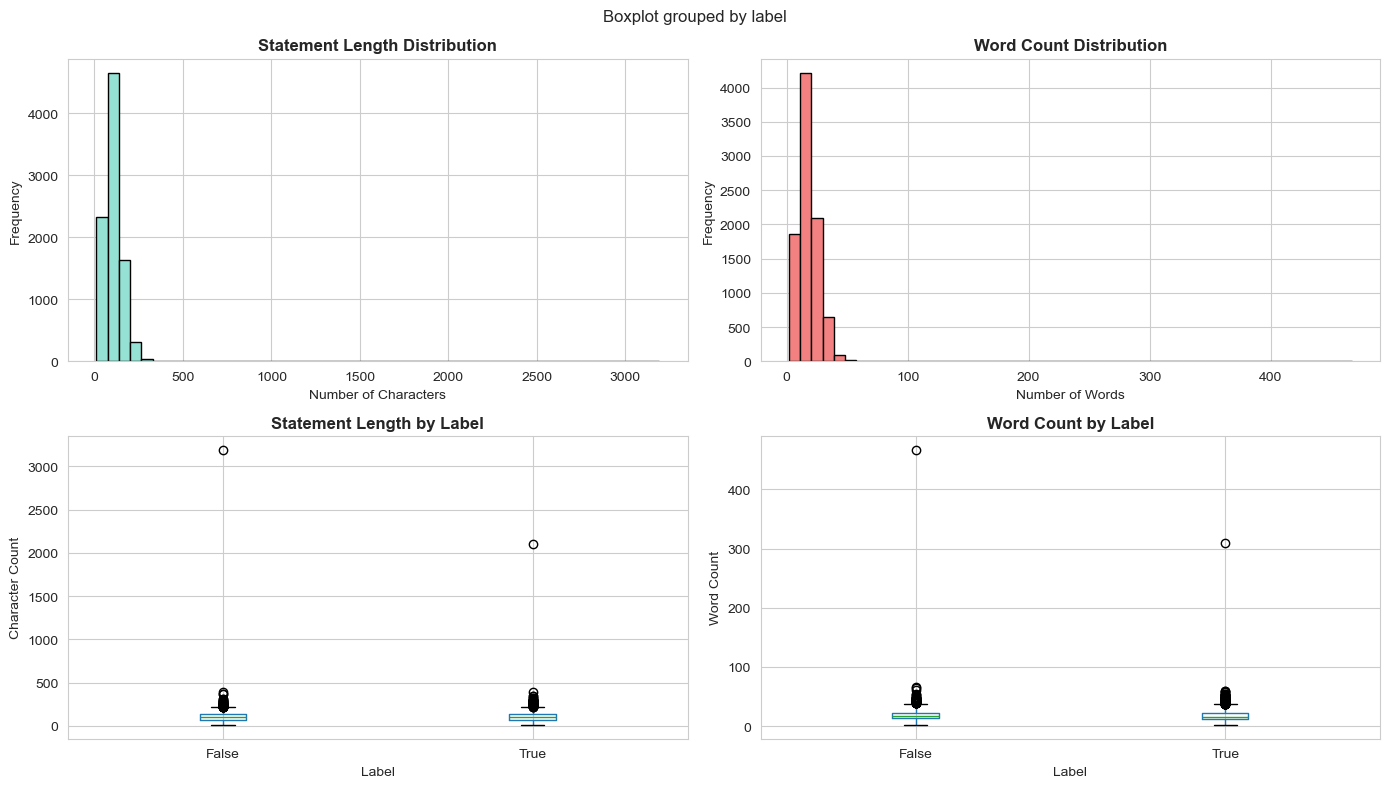


Sample statements:

True statements (label=1):
0    China is in the South China Sea and (building)...
3    Says her representation of an ex-boyfriend who...

False statements (label=0):
1    With the resources it takes to execute just ov...
2    The (Wisconsin) governor has proposed tax give...


In [7]:
# Text Feature Analysis (Statement Column)
print("="*60)
print("TEXT FEATURE ANALYSIS (Statement)")
print("="*60)

# Calculate text statistics
df['statement_length'] = df['statement'].str.len()
df['word_count'] = df['statement'].str.split().str.len()

print(f"\nStatement Length Statistics:")
print(df['statement_length'].describe())

print(f"\nWord Count Statistics:")
print(df['word_count'].describe())

# Check duplicate statements
statement_duplicates = df['statement'].duplicated().sum()
statement_unique = df['statement'].nunique()
print(f"\nDuplicate statements: {statement_duplicates}")
print(f"Unique statements: {statement_unique}")

# Show the 10 longest statements
top_10_longest = df[['statement', 'statement_length', 'word_count']].sort_values(
    by=['statement_length', 'word_count'], ascending=[False, False]
).head(10)

print("\nTop 10 longest statements:")
print(top_10_longest.to_string(index=False))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Statement length distribution
axes[0, 0].hist(df['statement_length'], bins=50, color='#95E1D3', edgecolor='black')
axes[0, 0].set_title('Statement Length Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Number of Characters')
axes[0, 0].set_ylabel('Frequency')

# Word count distribution
axes[0, 1].hist(df['word_count'], bins=50, color='#F38181', edgecolor='black')
axes[0, 1].set_title('Word Count Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Number of Words')
axes[0, 1].set_ylabel('Frequency')

# Statement length by label
df.boxplot(column='statement_length', by='label', ax=axes[1, 0])
axes[1, 0].set_title('Statement Length by Label', fontweight='bold')
axes[1, 0].set_xlabel('Label')
axes[1, 0].set_ylabel('Character Count')
plt.sca(axes[1, 0])
plt.xticks([1, 2], ['False', 'True'])

# Word count by label
df.boxplot(column='word_count', by='label', ax=axes[1, 1])
axes[1, 1].set_title('Word Count by Label', fontweight='bold')
axes[1, 1].set_xlabel('Label')
axes[1, 1].set_ylabel('Word Count')
plt.sca(axes[1, 1])
plt.xticks([1, 2], ['False', 'True'])

plt.tight_layout()
plt.show()

print("\nSample statements:")
print("\nTrue statements (label=1):")
print(df[df['label'] == 1]['statement'].head(2).to_string())
print("\nFalse statements (label=0):")
print(df[df['label'] == 0]['statement'].head(2).to_string())

In [8]:
# Analysis of the most polluted statements
print("="*60)
print("MOST POLLUTED STATEMENTS")
print("="*60)

statement_text = df['statement'].fillna('').astype(str)
pollution_df = pd.DataFrame({
    'id': df['id'],
    'label': df['label'],
    'statement': statement_text,
    'statement_length': statement_text.str.len(),
    'word_count': statement_text.str.split().str.len(),
    'tab_count': statement_text.str.count('\t'),
    'newline_count': statement_text.str.count('\n'),
    'url_count': statement_text.str.count(r'https?://|www\.'),
    'quote_count': statement_text.str.count('"') + statement_text.str.count("'"),
    'special_char_count': statement_text.str.count(r'[^A-Za-z0-9\s]'),
})

pollution_df['special_char_ratio'] = pollution_df['special_char_count'] / pollution_df['statement_length'].clip(lower=1)
pollution_df['length_to_word_ratio'] = pollution_df['statement_length'] / pollution_df['word_count'].clip(lower=1)
pollution_df['tab_to_word_ratio'] = pollution_df['tab_count'] / pollution_df['word_count'].clip(lower=1)
pollution_df['row_spillover_flag'] = (pollution_df['tab_count'] >= 3) | (pollution_df['newline_count'] > 0)
pollution_df['pollution_score'] = (
    pollution_df['tab_count'] * 25 +
    pollution_df['newline_count'] * 25 +
    pollution_df['url_count'] * 4 +
    pollution_df['quote_count'] * 2 +
    pollution_df['special_char_ratio'] * 10 +
    pollution_df['tab_to_word_ratio'].clip(upper=10) * 10 +
    pollution_df['length_to_word_ratio'].clip(upper=30)
 )

# Helpful summary flags
has_tabs = (pollution_df['tab_count'] > 0).sum()
has_newlines = (pollution_df['newline_count'] > 0).sum()
has_urls = (pollution_df['url_count'] > 0).sum()
high_symbol_density = (pollution_df['special_char_ratio'] > 0.20).sum()
row_spillovers = pollution_df['row_spillover_flag'].sum()

print(f"Statements with tab characters: {has_tabs}")
print(f"Statements with newline characters: {has_newlines}")
print(f"Statements with URLs: {has_urls}")
print(f"Statements with high symbol density (> 20%): {high_symbol_density}")
print(f"Statements that look like row spillover: {row_spillovers}")

# Show the most polluted examples
top_polluted = pollution_df.sort_values(
    by=['pollution_score', 'statement_length'], ascending=[False, False]
 ).head(10)

top_polluted = top_polluted.assign(
    statement_preview=top_polluted['statement'].str.replace(r'\s+', ' ', regex=True).str.slice(0, 220)
 )

print("\nTop 10 polluted statements:")
print(
    top_polluted[[
        'id',
        'label',
        'pollution_score',
        'statement_length',
        'word_count',
        'tab_count',
        'newline_count',
        'url_count',
        'quote_count',
        'special_char_ratio',
        'tab_to_word_ratio',
        'row_spillover_flag',
        'statement_preview',
    ]].to_string(index=False)
 )

# A quick look at the corruption pattern itself
print("\nPollution pattern summary:")
pattern_summary = pd.DataFrame({
    'Signal': [
        'Tabs',
        'Newlines',
        'URLs',
        'High symbol density',
        'Row spillover',
    ],
    'Count': [
        has_tabs,
        has_newlines,
        has_urls,
        high_symbol_density,
        row_spillovers,
    ]
})
print(pattern_summary.to_string(index=False))

MOST POLLUTED STATEMENTS
Statements with tab characters: 3
Statements with newline characters: 3
Statements with URLs: 0
Statements with high symbol density (> 20%): 2
Statements that look like row spillover: 3

Top 10 polluted statements:
         id  label  pollution_score  statement_length  word_count  tab_count  newline_count  url_count  quote_count  special_char_ratio  tab_to_word_ratio  row_spillover_flag                                                                                                                                                                                                            statement_preview
5272ec544cf      0      4216.548396              3192         467        156             12          0            3            0.037281           0.334047                True Hospitals, doctors, MRIs, surgeries and so forth are more extensively used and far more expensive in this country than they are in many other countries.'' health-care mitt-romney Former gov

In [9]:
# Summary Statistics & ML Readiness
print("="*60)
print("SUMMARY STATISTICS & DATA QUALITY")
print("="*60)

summary_stats = {
    'Total Records': len(df),
    'Total Features': len(df.columns),
    'Numeric Features': len(df.select_dtypes(include=[np.number]).columns),
    'Categorical Features': len(df.select_dtypes(include=['object']).columns),
    'Missing Values': df.isnull().sum().sum(),
    'Duplicate Rows': df.duplicated().sum(),
}

for key, value in summary_stats.items():
    print(f"{key:.<40} {value:>15}")

print("\n" + "="*60)
print("FEATURE-BY-FEATURE SUMMARY")
print("="*60)
feature_summary = pd.DataFrame({
    'Feature': df.columns,
    'Type': [df[col].dtype for col in df.columns],
    'Non-Null Count': [df[col].notna().sum() for col in df.columns],
    'Unique Values': [df[col].nunique() for col in df.columns],
})
print(feature_summary.to_string(index=False))

print("\n" + "="*60)
print("RECOMMENDATIONS FOR ML PREPROCESSING")
print("="*60)
recommendations = [
    "✓ No missing values detected - good data quality",
    "• Text preprocessing: tokenization, lowercasing, punctuation removal",
    "• Categorical encoding: label encoding or one-hot encoding for party_affiliation, subject",
    "• Handle class imbalance if present (check ratio above)",
    "• Consider TF-IDF or word embeddings for 'statement' feature",
    "• Feature engineering: extract text features (length, word count already calculated)",
    "• Consider temporal/frequency features from speaker and subject",
]
for rec in recommendations:
    print(rec)

SUMMARY STATISTICS & DATA QUALITY
Total Records...........................            8950
Total Features..........................              10
Numeric Features........................               3
Categorical Features....................               7
Missing Values..........................            4412
Duplicate Rows..........................               0

FEATURE-BY-FEATURE SUMMARY
          Feature  Type  Non-Null Count  Unique Values
               id   str            8950           8950
            label int64            8950              2
        statement   str            8950           8939
          subject   str            8950           3409
          speaker   str            8950           2634
      speaker_job   str            6468           1090
       state_info   str            7020             78
party_affiliation   str            8950             24
 statement_length int64            8950            279
       word_count int64            8950       

C:\Users\CmdrC\AppData\Local\Temp\ipykernel_23588\3360825415.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  'Categorical Features': len(df.select_dtypes(include=['object']).columns),


## ID preprocessing (`id` unique identifier)

For ML training, `id` should **not** be used as a predictive feature because it is an identifier, not a signal of truthfulness.

Recommended handling:
- Keep `id` for traceability (link predictions back to original records).
- Validate quality of `id` (missing values and uniqueness).
- Exclude `id` from model input features.
- Optionally use a hash of `id` to create stable train/validation splits.

In [10]:
# ID preprocessing for ML safety
import hashlib

# 1) Normalize id format
id_series = df['id'].astype(str).str.strip()

# 2) Validate quality
id_missing = id_series.isna().sum() + (id_series == '').sum()
id_duplicates = id_series.duplicated().sum()

print('=' * 60)
print('ID QUALITY CHECK')
print('=' * 60)
print(f'Total rows: {len(df):,}')
print(f'Missing/empty IDs: {id_missing:,}')
print(f'Duplicate IDs: {id_duplicates:,}')
print(f'Unique IDs: {id_series.nunique():,}')

# 3) Keep id only for traceability (do not feed to model)
df_with_id = df.copy()
df_with_id['id'] = id_series

# ML-ready dataframe: exclude identifier column to prevent leakage/noise
df_ml = df_with_id.drop(columns=['id'])
print(f"\nML-ready shape (without 'id'): {df_ml.shape}")

# 4) Optional: stable hash bucket from id for reproducible split assignment
#    Useful for repeatable train/validation splits across runs.
def id_to_bucket(x, n_buckets=100):
    digest = hashlib.md5(x.encode('utf-8')).hexdigest()
    return int(digest, 16) % n_buckets

df_with_id['id_bucket'] = id_series.apply(id_to_bucket)
print("Created 'id_bucket' (0-99) for optional stable split strategy.")

# Example split rule (not applied automatically):
#   validation_set = df_with_id[df_with_id['id_bucket'] < 20]   # 20%
#   train_set = df_with_id[df_with_id['id_bucket'] >= 20]       # 80%

ID QUALITY CHECK
Total rows: 8,950
Missing/empty IDs: 0
Duplicate IDs: 0
Unique IDs: 8,950

ML-ready shape (without 'id'): (8950, 9)
Created 'id_bucket' (0-99) for optional stable split strategy.


## Label preprocessing (`label` truthfulness target)

Goal: create a clean binary target for ML training.

Best practice:
- Ensure `label` has only two valid classes.
- Convert labels to integer binary format.
- Keep a clear interpretation: `1 = false claim` (fake) and `0 = true claim`.
- Check class balance and compute class weights for imbalanced training.

In [11]:
# Label preprocessing for binary classification
from sklearn.utils.class_weight import compute_class_weight

print('=' * 60)
print('LABEL PREPROCESSING')
print('=' * 60)

raw_label = df['label'].copy()

# Normalize text labels defensively (if labels are strings in any future file)
if raw_label.dtype == 'object':
    normalized = raw_label.astype(str).str.strip().str.lower()
    label_map = {
        'false': 1,
        'fake': 1,
        'mostly-false': 1,
        'pants-fire': 1,
        'true': 0,
        'mostly-true': 0,
    }
    y = normalized.map(label_map)
else:
    # Numeric labels path (current dataset expectation)
    y = pd.to_numeric(raw_label, errors='coerce')

# Validate missing/invalid labels
invalid_mask = y.isna()
invalid_count = invalid_mask.sum()
if invalid_count > 0:
    print(f'Warning: found {invalid_count} invalid labels. Dropping these rows for training.')

# Keep only valid rows and force integer binary labels
valid_df = df.loc[~invalid_mask].copy()
y = y.loc[~invalid_mask].astype(int)

# Ensure strict binary classes {0, 1} (remap if needed)
unique_classes = sorted(y.unique().tolist())
if unique_classes != [0, 1]:
    print(f'Info: observed classes {unique_classes}, remapping to binary using rank order.')
    class_to_binary = {cls: i for i, cls in enumerate(unique_classes)}
    y = y.map(class_to_binary).astype(int)

print(f'Rows used for training target: {len(y):,}')
print(f'Unique target classes: {sorted(y.unique().tolist())}')

# Class balance report
class_counts = y.value_counts().sort_index()
class_pct = y.value_counts(normalize=True).sort_index() * 100
print('\nClass distribution:')
for cls in class_counts.index:
    meaning = 'false claim' if cls == 1 else 'true claim'
    print(f'  class {cls} ({meaning}): {class_counts[cls]:,} rows ({class_pct[cls]:.2f}%)')

# Optional class weights for imbalanced training
classes = np.array(sorted(y.unique()))
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, weights)}
print(f'\nSuggested class_weight for models: {class_weight_dict}')

# Save ML-ready target and aligned features
y_ml = y
X_ml = valid_df.drop(columns=['label'])

print(f'X_ml shape: {X_ml.shape}')
print(f'y_ml shape: {y_ml.shape}')
print('Label preprocessing complete.')

LABEL PREPROCESSING
Rows used for training target: 8,950
Unique target classes: [0, 1]

Class distribution:
  class 0 (true claim): 3,155 rows (35.25%)
  class 1 (false claim): 5,795 rows (64.75%)

Suggested class_weight for models: {0: 1.4183835182250397, 1: 0.7722174288179465}
X_ml shape: (8950, 9)
y_ml shape: (8950,)
Label preprocessing complete.


## Statement preprocessing (`statement` text of the claim)

Goal: convert raw claim text into clean, model-ready input.

This block performs:
- Basic text cleaning (lowercasing, URL/HTML cleanup, whitespace normalization)
- Safe handling of missing statements
- Optional stopword removal and light stemming (toggle)
- Creation of a clean text column for vectorizers
- Creation of lightweight text features for classical ML models

In [12]:
# Statement preprocessing for ML
import re

# Optional NLP tools (fallback if nltk is unavailable)
USE_STOPWORD_REMOVAL = False
USE_STEMMING = False

try:
    from nltk.corpus import stopwords
    from nltk.stem import PorterStemmer

    # Attempt to load resources; if missing, disable optional steps gracefully
    try:
        _ = stopwords.words('english')
        stop_words = set(stopwords.words('english'))
    except LookupError:
        stop_words = set()
        USE_STOPWORD_REMOVAL = False

    stemmer = PorterStemmer()
except Exception:
    stop_words = set()
    stemmer = None
    USE_STOPWORD_REMOVAL = False
    USE_STEMMING = False

print('=' * 60)
print('STATEMENT PREPROCESSING')
print('=' * 60)

# 1) Safe text extraction
statement_raw = df['statement'].fillna('').astype(str)

# 2) Cleaning function
def clean_statement(text):
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)  # Remove HTML tags
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)  # Remove URLs
    text = re.sub(r"[^a-z0-9\s'?!.,-]", ' ', text)  # Keep useful punctuation
    text = re.sub(r'\s+', ' ', text).strip()  # Normalize spaces
    return text

# 3) Optional token-level processing
def normalize_tokens(text):
    tokens = text.split()

    if USE_STOPWORD_REMOVAL and stop_words:
        tokens = [t for t in tokens if t not in stop_words]

    if USE_STEMMING and stemmer is not None:
        tokens = [stemmer.stem(t) for t in tokens]

    return ' '.join(tokens)

statement_clean = statement_raw.apply(clean_statement)
statement_clean = statement_clean.apply(normalize_tokens)

# 4) Save model-ready text column
df_statement = df.copy()
df_statement['statement_clean'] = statement_clean

# 5) Lightweight text features for classical models
df_statement['statement_char_len_clean'] = df_statement['statement_clean'].str.len()
df_statement['statement_word_count_clean'] = df_statement['statement_clean'].str.split().str.len()
df_statement['statement_upper_ratio_raw'] = statement_raw.apply(
    lambda s: (sum(ch.isupper() for ch in s) / max(len(s), 1))
)
df_statement['statement_exclamation_count_raw'] = statement_raw.str.count('!')
df_statement['statement_question_count_raw'] = statement_raw.str.count(r'\?')
df_statement['statement_digit_ratio_clean'] = df_statement['statement_clean'].apply(
    lambda s: (sum(ch.isdigit() for ch in s) / max(len(s), 1))
)

# 6) Basic quality checks
empty_after_clean = (df_statement['statement_clean'].str.len() == 0).sum()
print(f'Total rows: {len(df_statement):,}')
print(f'Empty statements after cleaning: {empty_after_clean:,}')
print(f'Using stopword removal: {USE_STOPWORD_REMOVAL}')
print(f'Using stemming: {USE_STEMMING}')

print('\nSample before/after:')
sample_view = pd.DataFrame({
    'statement_raw': statement_raw.head(3),
    'statement_clean': df_statement['statement_clean'].head(3)
})
print(sample_view.to_string(index=False))

# 7) ML-ready text and features
df_text_ml = df_statement.copy()
X_text = df_text_ml['statement_clean']

print('\nCreated:')
print("- df_text_ml (dataset with cleaned statement + text features)")
print("- X_text (clean text series for TF-IDF/embeddings)")

STATEMENT PREPROCESSING
Total rows: 8,950
Empty statements after cleaning: 0
Using stopword removal: False
Using stemming: False

Sample before/after:
                                                                                                                                                       statement_raw                                                                                                                                                      statement_clean
                                                China is in the South China Sea and (building)a military fortress the likes of which perhaps the world has not seen.                                                  china is in the south china sea and building a military fortress the likes of which perhaps the world has not seen.
With the resources it takes to execute just over three months of the Iraq war, we could fully fund the expansion of health care for needy children that Bush vetoed. with the resources it ta

## Subject preprocessing (`subject` topic or topics of the claim)

Goal: turn the subject field into a consistent feature for ML.

Recommended handling:
- Normalize subject text to lowercase and clean punctuation.
- Preserve the original subject for traceability.
- Detect and split multi-topic values when the field contains separators like commas, slashes, or pipes.
- Create a cleaned subject feature plus simple topic-count features.
- Use the cleaned subject as input to one-hot encoding, frequency encoding, or TF-IDF depending on cardinality.

In [13]:
# Subject preprocessing for ML
import re

print('=' * 60)
print('SUBJECT PREPROCESSING')
print('=' * 60)

subject_raw = df['subject'].fillna('').astype(str)

# Clean and normalize subject text
# This keeps the subject usable for one-hot / frequency encoding / TF-IDF.
def clean_subject(text):
    text = text.lower().strip()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'[\|/;]+', ',', text)  # Normalize separators
    text = re.sub(r'[^a-z0-9,\s&-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Split multi-topic subjects into a list of topics
def split_subjects(text):
    if not text:
        return []
    parts = re.split(r'[,|/;]+', text)
    parts = [p.strip() for p in parts if p.strip()]
    return parts

subject_clean = subject_raw.apply(clean_subject)
subject_topics = subject_clean.apply(split_subjects)
subject_primary = subject_topics.apply(lambda x: x[0] if len(x) > 0 else 'unknown')
subject_topic_count = subject_topics.apply(len)
subject_has_multiple_topics = subject_topic_count.gt(1).astype(int)

# Create ML-ready subject dataframe
df_subject = df.copy()
df_subject['subject_clean'] = subject_clean
df_subject['subject_primary'] = subject_primary
df_subject['subject_topic_count'] = subject_topic_count
df_subject['subject_has_multiple_topics'] = subject_has_multiple_topics

# Optional rare-category handling for high-cardinality subjects
subject_value_counts = df_subject['subject_primary'].value_counts()
rare_threshold = 10
rare_subjects = subject_value_counts[subject_value_counts < rare_threshold].index

df_subject['subject_primary_grouped'] = df_subject['subject_primary'].where(
    ~df_subject['subject_primary'].isin(rare_subjects),
    'other'
)

# Quality checks
empty_subjects = (df_subject['subject_clean'].str.len() == 0).sum()
print(f'Total rows: {len(df_subject):,}')
print(f'Empty subjects after cleaning: {empty_subjects:,}')
print(f'Unique primary subjects: {df_subject["subject_primary"].nunique():,}')
print(f'Rare subject threshold: < {rare_threshold} occurrences -> grouped as "other"')

print('\nTop 10 primary subjects:')
print(df_subject['subject_primary'].value_counts().head(10).to_string())

print('\nSample before/after:')
sample_subject = pd.DataFrame({
    'subject_raw': subject_raw.head(5),
    'subject_clean': df_subject['subject_clean'].head(5),
    'subject_primary': df_subject['subject_primary'].head(5),
    'topic_count': df_subject['subject_topic_count'].head(5)
})
print(sample_subject.to_string(index=False))

# ML-ready outputs
X_subject = df_subject[['subject_clean', 'subject_primary_grouped', 'subject_topic_count', 'subject_has_multiple_topics']]
print('\nCreated:')
print('- df_subject (dataset with cleaned subject features)')
print('- X_subject (subject-ready feature frame)')

SUBJECT PREPROCESSING
Total rows: 8,950
Empty subjects after cleaning: 0
Unique primary subjects: 139
Rare subject threshold: < 10 occurrences -> grouped as "other"

Top 10 primary subjects:
subject_primary
economy                 776
health-care             651
candidates-biography    527
education               477
elections               381
federal-budget          326
immigration             279
crime                   276
taxes                   271
foreign-policy          263

Sample before/after:
                                               subject_raw                                              subject_clean      subject_primary  topic_count
                             china,foreign-policy,military                              china,foreign-policy,military                china            3
                                               health-care                                                health-care          health-care            1
                  corporations,pund

## Speaker preprocessing (`speaker` person making the claim)

Goal: use speaker information carefully because this is usually a high-cardinality field.

Recommended handling:
- Normalize speaker names to a consistent format.
- Keep the raw speaker name for traceability.
- Avoid direct one-hot encoding for every speaker unless the dataset is small.
- Prefer frequency encoding, rare-speaker grouping, and simple name-shape features.
- If using target encoding, fit it only inside cross-validation folds to avoid leakage.

In [14]:
# Speaker preprocessing for ML
import re

print('=' * 60)
print('SPEAKER PREPROCESSING')
print('=' * 60)

speaker_raw = df['speaker'].fillna('').astype(str)

# Normalize speaker names for consistent matching
# This intentionally keeps the original speaker column intact elsewhere.
def clean_speaker(text):
    text = text.strip().lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

speaker_clean = speaker_raw.apply(clean_speaker)
speaker_clean = speaker_clean.replace('', 'unknown')

# Frequency encoding and rarity handling
speaker_counts = speaker_clean.value_counts()
speaker_frequency = speaker_clean.map(speaker_counts).astype(int)
speaker_total = len(speaker_clean)
speaker_frequency_pct = speaker_frequency / speaker_total

rare_threshold = 5
speaker_is_rare = speaker_frequency.lt(rare_threshold).astype(int)
speaker_grouped = speaker_clean.where(~speaker_clean.isin(speaker_counts[speaker_counts < rare_threshold].index), 'other')

# Simple name-shape features
speaker_token_count = speaker_clean.apply(lambda x: len(x.split()))
speaker_char_len = speaker_clean.str.len()
speaker_has_comma = speaker_raw.str.contains(',', regex=False).astype(int)
speaker_has_period = speaker_raw.str.contains('.', regex=False).astype(int)
speaker_has_title = speaker_raw.str.contains(r'\b(mr|mrs|ms|dr|gov|sen|rep|pres|prof)\b', case=False, regex=True).astype(int)

# Create ML-ready speaker dataframe
df_speaker = df.copy()
df_speaker['speaker_clean'] = speaker_clean
df_speaker['speaker_grouped'] = speaker_grouped
df_speaker['speaker_frequency'] = speaker_frequency
df_speaker['speaker_frequency_pct'] = speaker_frequency_pct
(df_speaker['speaker_is_rare'], df_speaker['speaker_token_count'], df_speaker['speaker_char_len']) = (
    speaker_is_rare,
    speaker_token_count,
    speaker_char_len,
)
df_speaker['speaker_has_comma'] = speaker_has_comma
df_speaker['speaker_has_period'] = speaker_has_period
df_speaker['speaker_has_title'] = speaker_has_title

# Quality checks
empty_speakers = (df_speaker['speaker_clean'] == 'unknown').sum()
print(f'Total rows: {len(df_speaker):,}')
print(f'Unknown/empty speakers: {empty_speakers:,}')
print(f'Unique speakers: {df_speaker["speaker_clean"].nunique():,}')
print(f'Rare speaker threshold: < {rare_threshold} occurrences -> grouped as "other"')

print('\nTop 10 speakers by frequency:')
print(df_speaker['speaker_clean'].value_counts().head(10).to_string())

print('\nSample before/after:')
sample_speaker = pd.DataFrame({
    'speaker_raw': speaker_raw.head(5),
    'speaker_clean': df_speaker['speaker_clean'].head(5),
    'speaker_grouped': df_speaker['speaker_grouped'].head(5),
    'frequency': df_speaker['speaker_frequency'].head(5),
    'is_rare': df_speaker['speaker_is_rare'].head(5)
})
print(sample_speaker.to_string(index=False))

# ML-ready outputs
X_speaker = df_speaker[[
    'speaker_clean',
    'speaker_grouped',
    'speaker_frequency',
    'speaker_frequency_pct',
    'speaker_is_rare',
    'speaker_token_count',
    'speaker_char_len',
    'speaker_has_comma',
    'speaker_has_period',
    'speaker_has_title',
]]



SPEAKER PREPROCESSING
Total rows: 8,950
Unknown/empty speakers: 0
Unique speakers: 2,634
Rare speaker threshold: < 5 occurrences -> grouped as "other"

Top 10 speakers by frequency:
speaker_clean
barack-obama       435
donald-trump       247
hillary-clinton    204
mitt-romney        142
john-mccain        139
chain-email        128
scott-walker       123
rick-perry         117
rick-scott         105
marco-rubio         99

Sample before/after:
               speaker_raw              speaker_clean            speaker_grouped  frequency  is_rare
              donald-trump               donald-trump               donald-trump        247        0
                chris-dodd                 chris-dodd                 chris-dodd          7        0
             donna-brazile              donna-brazile              donna-brazile          9        0
           rebecca-bradley            rebecca-bradley                      other          2        1
republican-party-wisconsin republican-party-wis

C:\Users\CmdrC\AppData\Local\Temp\ipykernel_23588\1342438797.py:36: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  speaker_has_title = speaker_raw.str.contains(r'\b(mr|mrs|ms|dr|gov|sen|rep|pres|prof)\b', case=False, regex=True).astype(int)


## Speaker job preprocessing (`speaker_job` occupation of the speaker)

Goal: normalize speaker occupation text and convert it into ML-friendly categorical features.

Recommended handling:
- Clean and standardize occupation strings.
- Keep the raw occupation for traceability.
- Group rare occupations into an `other` bucket.
- Add frequency-based and shape-based features.
- Use one-hot encoding for common occupations and frequency encoding for sparse ones.

In [15]:
# Speaker job preprocessing for ML
import re

print('=' * 60)
print('SPEAKER JOB PREPROCESSING')
print('=' * 60)

speaker_job_raw = df['speaker_job'].fillna('').astype(str)

# Normalize occupation text
# We keep the raw value in the dataframe and derive cleaned features for modeling.
def clean_speaker_job(text):
    text = text.strip().lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

speaker_job_clean = speaker_job_raw.apply(clean_speaker_job)
speaker_job_clean = speaker_job_clean.replace('', 'unknown')

# Frequency encoding and rare-category grouping
speaker_job_counts = speaker_job_clean.value_counts()
speaker_job_frequency = speaker_job_clean.map(speaker_job_counts).astype(int)
speaker_job_total = len(speaker_job_clean)
speaker_job_frequency_pct = speaker_job_frequency / speaker_job_total

rare_threshold = 10
rare_jobs = speaker_job_counts[speaker_job_counts < rare_threshold].index
speaker_job_grouped = speaker_job_clean.where(~speaker_job_clean.isin(rare_jobs), 'other')
speaker_job_is_rare = speaker_job_clean.isin(rare_jobs).astype(int)

# Basic job-shape features
speaker_job_token_count = speaker_job_clean.apply(lambda x: len(x.split()))
speaker_job_char_len = speaker_job_clean.str.len()
speaker_job_has_slash = speaker_job_raw.str.contains('/', regex=False).astype(int)
speaker_job_has_ampersand = speaker_job_raw.str.contains('&', regex=False).astype(int)
speaker_job_has_title_case = speaker_job_raw.str.contains(r'\b(ceo|cfo|cto|professor|doctor|dr|senator|judge|mayor|governor|attorney|lawyer)\b', case=False, regex=True).astype(int)

# Create ML-ready speaker_job dataframe
df_speaker_job = df.copy()
df_speaker_job['speaker_job_clean'] = speaker_job_clean
df_speaker_job['speaker_job_grouped'] = speaker_job_grouped
df_speaker_job['speaker_job_frequency'] = speaker_job_frequency
df_speaker_job['speaker_job_frequency_pct'] = speaker_job_frequency_pct
df_speaker_job['speaker_job_is_rare'] = speaker_job_is_rare
df_speaker_job['speaker_job_token_count'] = speaker_job_token_count
df_speaker_job['speaker_job_char_len'] = speaker_job_char_len
df_speaker_job['speaker_job_has_slash'] = speaker_job_has_slash
df_speaker_job['speaker_job_has_ampersand'] = speaker_job_has_ampersand
df_speaker_job['speaker_job_has_title_case'] = speaker_job_has_title_case

# Quality checks
unknown_jobs = (df_speaker_job['speaker_job_clean'] == 'unknown').sum()
print(f'Total rows: {len(df_speaker_job):,}')
print(f'Unknown/empty speaker_job values: {unknown_jobs:,}')
print(f'Unique speaker_job values: {df_speaker_job["speaker_job_clean"].nunique():,}')
print(f'Rare job threshold: < {rare_threshold} occurrences -> grouped as "other"')

print('\nTop 10 speaker jobs by frequency:')
print(df_speaker_job['speaker_job_clean'].value_counts().head(10).to_string())

print('\nSample before/after:')
sample_job = pd.DataFrame({
    'speaker_job_raw': speaker_job_raw.head(5),
    'speaker_job_clean': df_speaker_job['speaker_job_clean'].head(5),
    'speaker_job_grouped': df_speaker_job['speaker_job_grouped'].head(5),
    'frequency': df_speaker_job['speaker_job_frequency'].head(5),
    'is_rare': df_speaker_job['speaker_job_is_rare'].head(5)
})
print(sample_job.to_string(index=False))

# ML-ready outputs
X_speaker_job = df_speaker_job[[
    'speaker_job_clean',
    'speaker_job_grouped',
    'speaker_job_frequency',
    'speaker_job_frequency_pct',
    'speaker_job_is_rare',
    'speaker_job_token_count',
    'speaker_job_char_len',
    'speaker_job_has_slash',
    'speaker_job_has_ampersand',
    'speaker_job_has_title_case',
]]

print('\nCreated:')
print('- df_speaker_job (dataset with cleaned speaker_job features)')
print('- X_speaker_job (speaker_job-ready feature frame)')

SPEAKER JOB PREPROCESSING
Total rows: 8,950
Unknown/empty speaker_job values: 2,482
Unique speaker_job values: 1,018
Rare job threshold: < 10 occurrences -> grouped as "other"

Top 10 speaker jobs by frequency:
speaker_job_clean
unknown                   2482
u.s. senator               627
president                  438
governor                   368
u.s. representative        260
president-elect            247
presidential candidate     216
state senator              186
state representative       155
former governor            143

Sample before/after:
      speaker_job_raw     speaker_job_clean   speaker_job_grouped  frequency  is_rare
      President-Elect       president-elect       president-elect        247        0
         U.S. senator          u.s. senator          u.s. senator        627        0
Political commentator political commentator political commentator         15        0
                                    unknown               unknown       2482        0
         

C:\Users\CmdrC\AppData\Local\Temp\ipykernel_23588\4096287905.py:37: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  speaker_job_has_title_case = speaker_job_raw.str.contains(r'\b(ceo|cfo|cto|professor|doctor|dr|senator|judge|mayor|governor|attorney|lawyer)\b', case=False, regex=True).astype(int)


## State info preprocessing (`state_info` geographic context)

Goal: standardize geographic context so it can be used as a stable metadata feature.

Recommended handling:
- Clean and normalize the location text.
- Detect whether the value refers to a U.S. state or abbreviation.
- Group rare geographic values into an `other` bucket.
- Use frequency-based features instead of treating every location as a separate category.
- Preserve the raw field for traceability.

In [16]:
# State info preprocessing for ML
import re

print('=' * 60)
print('STATE INFO PREPROCESSING')
print('=' * 60)

state_info_raw = df['state_info'].fillna('').astype(str)

# U.S. states + DC for basic geographic normalization
us_states = {
    'alabama': 'al', 'alaska': 'ak', 'arizona': 'az', 'arkansas': 'ar', 'california': 'ca',
    'colorado': 'co', 'connecticut': 'ct', 'delaware': 'de', 'district of columbia': 'dc',
    'florida': 'fl', 'georgia': 'ga', 'hawaii': 'hi', 'idaho': 'id', 'illinois': 'il',
    'indiana': 'in', 'iowa': 'ia', 'kansas': 'ks', 'kentucky': 'ky', 'louisiana': 'la',
    'maine': 'me', 'maryland': 'md', 'massachusetts': 'ma', 'michigan': 'mi', 'minnesota': 'mn',
    'mississippi': 'ms', 'missouri': 'mo', 'montana': 'mt', 'nebraska': 'ne', 'nevada': 'nv',
    'new hampshire': 'nh', 'new jersey': 'nj', 'new mexico': 'nm', 'new york': 'ny',
    'north carolina': 'nc', 'north dakota': 'nd', 'ohio': 'oh', 'oklahoma': 'ok', 'oregon': 'or',
    'pennsylvania': 'pa', 'rhode island': 'ri', 'south carolina': 'sc', 'south dakota': 'sd',
    'tennessee': 'tn', 'texas': 'tx', 'utah': 'ut', 'vermont': 'vt', 'virginia': 'va',
    'washington': 'wa', 'west virginia': 'wv', 'wisconsin': 'wi', 'wyoming': 'wy'
}
us_state_names = set(us_states.keys())
us_state_codes = set(us_states.values())

# Normalize geographic context text
def clean_state_info(text):
    text = text.strip().lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

state_info_clean = state_info_raw.apply(clean_state_info)
state_info_clean = state_info_clean.replace('', 'unknown')

# Detect U.S. state names or abbreviations

def normalize_state_value(text):
    if text in us_state_names:
        return text
    if text in us_state_codes:
        for name, code in us_states.items():
            if code == text:
                return name
    return text

state_info_normalized = state_info_clean.apply(normalize_state_value)
state_info_is_us_state = state_info_normalized.isin(us_state_names).astype(int)

# Frequency encoding and rare grouping
state_info_counts = state_info_normalized.value_counts()
state_info_frequency = state_info_normalized.map(state_info_counts).astype(int)
state_info_frequency_pct = state_info_frequency / len(state_info_normalized)

rare_threshold = 5
rare_state_values = state_info_counts[state_info_counts < rare_threshold].index
state_info_grouped = state_info_normalized.where(~state_info_normalized.isin(rare_state_values), 'other')
state_info_is_rare = state_info_normalized.isin(rare_state_values).astype(int)

# Basic shape features
state_info_token_count = state_info_normalized.apply(lambda x: len(x.split()))
state_info_char_len = state_info_normalized.str.len()
state_info_has_us_words = state_info_normalized.str.contains(r'\bus\b|\bunited states\b|\busa\b', regex=True).astype(int)

# Create ML-ready state info dataframe
df_state_info = df.copy()
df_state_info['state_info_clean'] = state_info_clean
df_state_info['state_info_normalized'] = state_info_normalized
df_state_info['state_info_grouped'] = state_info_grouped
df_state_info['state_info_frequency'] = state_info_frequency
df_state_info['state_info_frequency_pct'] = state_info_frequency_pct
df_state_info['state_info_is_rare'] = state_info_is_rare
df_state_info['state_info_is_us_state'] = state_info_is_us_state
df_state_info['state_info_token_count'] = state_info_token_count
df_state_info['state_info_char_len'] = state_info_char_len
df_state_info['state_info_has_us_words'] = state_info_has_us_words

# Quality checks
unknown_state_info = (df_state_info['state_info_normalized'] == 'unknown').sum()
print(f'Total rows: {len(df_state_info):,}')
print(f'Unknown/empty state_info values: {unknown_state_info:,}')
print(f'Unique normalized state_info values: {df_state_info["state_info_normalized"].nunique():,}')
print(f'Rows matching a U.S. state or DC: {df_state_info["state_info_is_us_state"].sum():,}')
print(f'Rare value threshold: < {rare_threshold} occurrences -> grouped as "other"')

print('\nTop 10 normalized state_info values:')
print(df_state_info['state_info_normalized'].value_counts().head(10).to_string())

print('\nSample before/after:')
sample_state_info = pd.DataFrame({
    'state_info_raw': state_info_raw.head(5),
    'state_info_clean': df_state_info['state_info_clean'].head(5),
    'state_info_normalized': df_state_info['state_info_normalized'].head(5),
    'grouped': df_state_info['state_info_grouped'].head(5),
    'is_us_state': df_state_info['state_info_is_us_state'].head(5)
})
print(sample_state_info.to_string(index=False))

# ML-ready outputs
X_state_info = df_state_info[[
    'state_info_clean',
    'state_info_normalized',
    'state_info_grouped',
    'state_info_frequency',
    'state_info_frequency_pct',
    'state_info_is_rare',
    'state_info_is_us_state',
    'state_info_token_count',
    'state_info_char_len',
    'state_info_has_us_words',
]]

print('\nCreated:')
print('- df_state_info (dataset with cleaned geographic features)')
print('- X_state_info (state_info-ready feature frame)')

STATE INFO PREPROCESSING
Total rows: 8,950
Unknown/empty state_info values: 1,932
Unique normalized state_info values: 62
Rows matching a U.S. state or DC: 6,903
Rare value threshold: < 5 occurrences -> grouped as "other"

Top 10 normalized state_info values:
state_info_normalized
unknown         1932
texas            879
florida          857
wisconsin        649
new york         580
illinois         489
ohio             410
georgia          385
virginia         369
rhode island     319

Sample before/after:
  state_info_raw state_info_clean state_info_normalized          grouped  is_us_state
        New York         new york              new york         new york            1
     Connecticut      connecticut           connecticut      connecticut            1
Washington, D.C. washington, d.c.      washington, d.c. washington, d.c.            0
                          unknown               unknown          unknown            0
       Wisconsin        wisconsin             wisconsin 

## Party affiliation preprocessing (`party_affiliation` political party of the speaker)

Goal: standardize party labels and turn them into compact categorical features.

Recommended handling:
- Clean and normalize party strings.
- Map common abbreviations to canonical names.
- Group uncommon parties into an `other` bucket.
- Add binary indicators for major parties when useful.
- Use one-hot encoding or frequency encoding depending on cardinality.

In [17]:
# Party affiliation preprocessing for ML
import re

print('=' * 60)
print('PARTY AFFILIATION PREPROCESSING')
print('=' * 60)

party_raw = df['party_affiliation'].fillna('').astype(str)

# Normalize common party labels and abbreviations
party_aliases = {
    'dem': 'democrat',
    'democrat': 'democrat',
    'democratic': 'democrat',
    'republican': 'republican',
    'rep': 'republican',
    'gop': 'republican',
    'ind': 'independent',
    'independent': 'independent',
    'libertarian': 'libertarian',
    'lib': 'libertarian',
    'green': 'green',
    'tea party': 'tea party',
    'unknown': 'unknown',
    'none': 'unknown',
    'na': 'unknown',
    'n/a': 'unknown',
    'other': 'other',
}

# Clean the raw string first
def clean_party(text):
    text = text.strip().lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[\._\-]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

party_clean = party_raw.apply(clean_party)

# Map aliases to canonical labels where possible
def canonical_party(text):
    if text in party_aliases:
        return party_aliases[text]
    if 'dem' in text:
        return 'democrat'
    if 'rep' in text or 'gop' in text:
        return 'republican'
    if 'ind' in text:
        return 'independent'
    if 'libert' in text:
        return 'libertarian'
    if 'green' in text:
        return 'green'
    if text == '':
        return 'unknown'
    return text

party_normalized = party_clean.apply(canonical_party)

# Frequency encoding and rare-category grouping
party_counts = party_normalized.value_counts()
party_frequency = party_normalized.map(party_counts).astype(int)
party_frequency_pct = party_frequency / len(party_normalized)

rare_threshold = 10
rare_parties = party_counts[party_counts < rare_threshold].index
party_grouped = party_normalized.where(~party_normalized.isin(rare_parties), 'other')
party_is_rare = party_normalized.isin(rare_parties).astype(int)

# Binary major-party indicator
party_is_major_party = party_normalized.isin(['democrat', 'republican']).astype(int)

# Basic shape features
party_token_count = party_normalized.apply(lambda x: len(x.split()))
party_char_len = party_normalized.str.len()
party_has_ampersand = party_raw.str.contains('&', regex=False).astype(int)
party_has_slash = party_raw.str.contains('/', regex=False).astype(int)

# Create ML-ready party dataframe
df_party = df.copy()
df_party['party_affiliation_clean'] = party_clean
df_party['party_affiliation_normalized'] = party_normalized
df_party['party_affiliation_grouped'] = party_grouped
df_party['party_affiliation_frequency'] = party_frequency
df_party['party_affiliation_frequency_pct'] = party_frequency_pct
df_party['party_affiliation_is_rare'] = party_is_rare
df_party['party_affiliation_is_major_party'] = party_is_major_party
df_party['party_affiliation_token_count'] = party_token_count
df_party['party_affiliation_char_len'] = party_char_len
df_party['party_affiliation_has_ampersand'] = party_has_ampersand
df_party['party_affiliation_has_slash'] = party_has_slash

# Quality checks
unknown_parties = (df_party['party_affiliation_normalized'] == 'unknown').sum()
print(f'Total rows: {len(df_party):,}')
print(f'Unknown/empty party_affiliation values: {unknown_parties:,}')
print(f'Unique normalized party values: {df_party["party_affiliation_normalized"].nunique():,}')
print(f'Major-party rows (democrat or republican): {df_party["party_affiliation_is_major_party"].sum():,}')
print(f'Rare value threshold: < {rare_threshold} occurrences -> grouped as "other"')

print('\nTop 10 normalized party values:')
print(df_party['party_affiliation_normalized'].value_counts().head(10).to_string())

print('\nSample before/after:')
sample_party = pd.DataFrame({
    'party_raw': party_raw.head(5),
    'party_clean': df_party['party_affiliation_clean'].head(5),
    'party_normalized': df_party['party_affiliation_normalized'].head(5),
    'grouped': df_party['party_affiliation_grouped'].head(5),
    'is_major_party': df_party['party_affiliation_is_major_party'].head(5)
})
print(sample_party.to_string(index=False))

# ML-ready outputs
X_party = df_party[[
    'party_affiliation_clean',
    'party_affiliation_normalized',
    'party_affiliation_grouped',
    'party_affiliation_frequency',
    'party_affiliation_frequency_pct',
    'party_affiliation_is_rare',
    'party_affiliation_is_major_party',
    'party_affiliation_token_count',
    'party_affiliation_char_len',
    'party_affiliation_has_ampersand',
    'party_affiliation_has_slash',
]]

print('\nCreated:')
print('- df_party (dataset with cleaned party features)')
print('- X_party (party_affiliation-ready feature frame)')

PARTY AFFILIATION PREPROCESSING
Total rows: 8,950
Unknown/empty party_affiliation values: 1,531
Unique normalized party values: 23
Major-party rows (democrat or republican): 6,846
Rare value threshold: < 10 occurrences -> grouped as "other"

Top 10 normalized party values:
party_affiliation_normalized
republican      3947
democrat        2899
unknown         1531
organization     197
independent      130
newsmaker         41
journalist        37
libertarian       34
columnist         32
activist          30

Sample before/after:
 party_raw party_clean party_normalized    grouped  is_major_party
republican  republican       republican republican               1
  democrat    democrat         democrat   democrat               1
  democrat    democrat         democrat   democrat               1
      none        none          unknown    unknown               0
republican  republican       republican republican               1

Created:
- df_party (dataset with cleaned party features)
- X_

SUBJECT: EXPLORATORY INSIGHTS & PLOTTING PLAN
Total rows: 8,950
Missing/empty subject: 0 (0.00%)
Unique primary subjects: 139
Top 20 subjects cover 65.61% of records

Top subjects:
subject
economy                    776
health-care                651
candidates-biography       527
education                  477
elections                  381
federal-budget             326
immigration                279
crime                      276
taxes                      271
foreign-policy             263
abortion                   230
energy                     219
state-budget               182
jobs                       175
campaign-finance           156
guns                       155
children                   145
congress                   134
deficit                    132
corrections-and-updates    117


C:\Users\CmdrC\AppData\Local\Temp\ipykernel_23588\1670119410.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, palette='viridis')


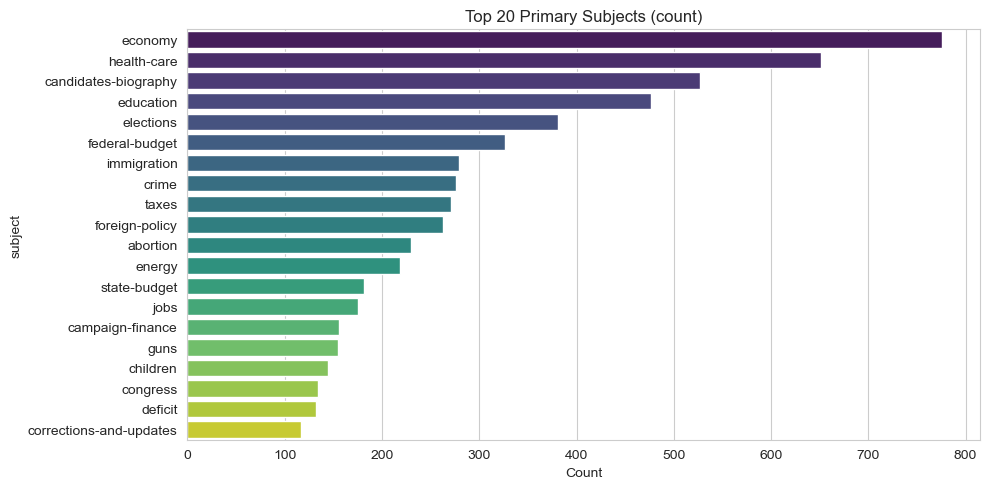

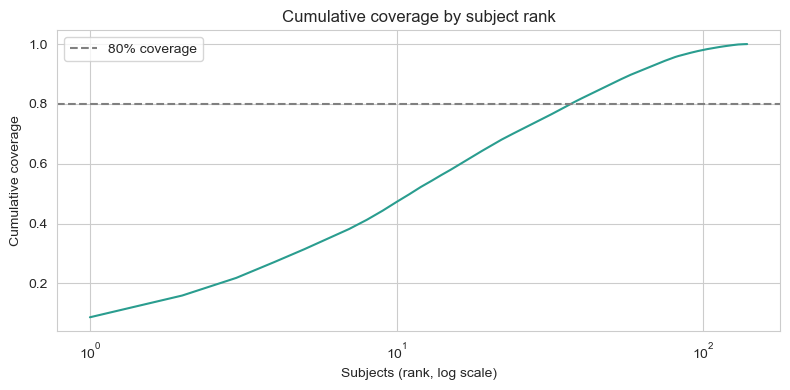

C:\Users\CmdrC\AppData\Local\Temp\ipykernel_23588\1670119410.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='false_rate', y=by_subject.index, data=by_subject.reset_index(), palette='rocket')


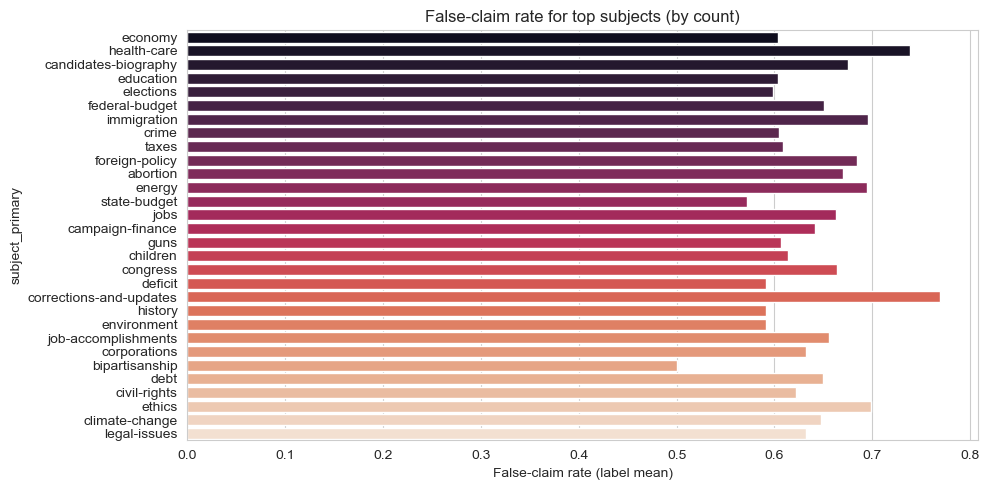

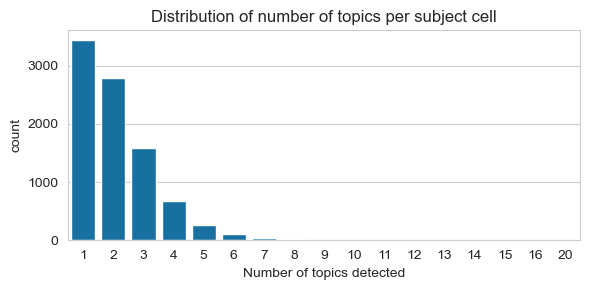


Distribution of number of topics per subject cell:
 topic_count  count  percentage
           1   3433       38.36
           2   2782       31.08
           3   1589       17.75
           4    677        7.56
           5    269        3.01
           6    103        1.15
           7     37        0.41
           8     23        0.26
           9     14        0.16
          10     10        0.11
          11      5        0.06
          12      1        0.01
          13      3        0.03
          14      1        0.01
          15      1        0.01
          16      1        0.01
          20      1        0.01

Subject length (chars) stats:
count    8950.000000
mean       23.382458
std        17.054637
min         4.000000
25%        11.000000
50%        20.000000
75%        31.000000
max       203.000000
Name: subject, dtype: float64

Top 50 longest subject rows:
                                                                                                                 

In [18]:
# Subject column insights & planned analytics
import matplotlib.pyplot as plt
import seaborn as sns
import re

print('=' * 60)
print('SUBJECT: EXPLORATORY INSIGHTS & PLOTTING PLAN')
print('=' * 60)

# Raw and cleaned subject strings
subject_raw = df['subject'].fillna('').astype(str)
subject_clean = subject_raw.str.lower().str.replace(r'[\|/;]+', ',', regex=True)
subject_clean = subject_clean.str.replace(r'[^a-z0-9,\s&-]', ' ', regex=True).str.replace(r'\s+', ' ', regex=True).str.strip()

# Primary subject (first topic) and topic counts
subject_primary = subject_clean.apply(lambda t: t.split(',')[0].strip() if t.strip() else 'unknown')
subject_topics = subject_clean.apply(lambda t: [p.strip() for p in re.split(r'[ ,|/;]+', t) if p.strip()] if t.strip() else [])
subject_topic_count = subject_topics.apply(len)

total = len(df)
missing = (subject_clean == '').sum()
unique_primary = subject_primary.nunique()

print(f'Total rows: {total:,}')
print(f'Missing/empty subject: {missing:,} ({missing/total*100:.2f}%)')
print(f'Unique primary subjects: {unique_primary:,}')

# Top subjects and coverage
top_n = 20
vc = subject_primary.value_counts()
top = vc.head(top_n)
top_coverage = top.sum() / total * 100
print(f'Top {top_n} subjects cover {top_coverage:.2f}% of records')
print('\nTop subjects:')
print(top.to_string())

# Plot 1: Top subjects bar chart
plt.figure(figsize=(10,5))
sns.barplot(x=top.values, y=top.index, palette='viridis')
plt.title(f'Top {top_n} Primary Subjects (count)')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

# Plot 2: Cumulative coverage of subjects
cum = vc.cumsum() / total
plt.figure(figsize=(8,4))
plt.plot(range(1, len(cum)+1), cum.values, color='#2a9d8f')
plt.axhline(0.8, color='gray', linestyle='--', label='80% coverage')
plt.xscale('log')
plt.xlabel('Subjects (rank, log scale)')
plt.ylabel('Cumulative coverage')
plt.title('Cumulative coverage by subject rank')
plt.legend()
plt.tight_layout()
plt.show()

# Plot 3: False-claim rate by top subjects
top_subjects = vc.head(30).index.tolist()
by_subject = df.assign(subject_primary=subject_primary).groupby('subject_primary')['label'].agg(['count','mean']).loc[top_subjects]
by_subject = by_subject.rename(columns={'mean':'false_rate','count':'count'})
plt.figure(figsize=(10,5))
sns.barplot(x='false_rate', y=by_subject.index, data=by_subject.reset_index(), palette='rocket')
plt.xlabel('False-claim rate (label mean)')
plt.title('False-claim rate for top subjects (by count)')
plt.tight_layout()
plt.show()

# Plot 4: Subject topic count distribution
plt.figure(figsize=(6,3))
sns.countplot(x=subject_topic_count, color='#0077b6')
plt.title('Distribution of number of topics per subject cell')
plt.xlabel('Number of topics detected')
plt.tight_layout()
plt.show()

# Table: Distribution of number of topics per subject cell (counts + percentage)
topic_dist = subject_topic_count.value_counts().sort_index()
topic_dist_df = pd.DataFrame({
    'topic_count': topic_dist.index,
    'count': topic_dist.values,
})
topic_dist_df['percentage'] = (topic_dist_df['count'] / total * 100).round(2)

print('\nDistribution of number of topics per subject cell:')
print(topic_dist_df.to_string(index=False))

# Subject length statistics
subject_char_len = subject_clean.str.len()
print('\nSubject length (chars) stats:')
print(subject_char_len.describe())

# Top 50 longest subject rows
longest_subject_rows = pd.DataFrame({
    'subject_raw': subject_raw,
    'subject_clean': subject_clean,
    'subject_primary': subject_primary,
    'topic_count': subject_topic_count,
    'subject_length': subject_char_len,
}).sort_values(by=['subject_length', 'topic_count'], ascending=[False, False]).head(50)

print('\nTop 50 longest subject rows:')
print(longest_subject_rows.to_string(index=False))

# Print sample mappings for manual inspection
print('\nSample subject raw -> primary (first 8):')
sample_df = pd.DataFrame({
    'subject_raw': subject_raw.head(8),
    'subject_clean': subject_clean.head(8),
    'subject_primary': subject_primary.head(8),
    'topic_count': subject_topic_count.head(8)
})
print(sample_df.to_string(index=False))

# Recommendations (printed) based on these insights
print('\nPreprocessing recommendations:')
print('- Normalize to lowercase and standardize separators (commas).')
print('- Split multi-topic cells; keep primary topic plus topic count/flag.')
print('- Group rare primary subjects (e.g., < 10 occurrences) into "other" for stability.')
print('- Use one-hot / top-K frequency encoding for top subjects; frequency encoding or embeddings for long tail.')
print('- Consider subject × speaker and subject × party interaction features and subject-level target rate (out-of-fold).')
print('- If subject text is long or free-form, consider TF-IDF on the subject field and clustering for taxonomy discovery.')

In [19]:
# Top 50 longest subject rows with compact preview
longest_subject_rows = pd.DataFrame({
    'subject_raw': subject_raw,
    'subject_clean': subject_clean,
    'subject_preview': subject_clean.str.slice(0, 120),
    'subject_primary': subject_primary,
    'topic_count': subject_topic_count,
    'subject_length': subject_char_len,
}).sort_values(by=['subject_length', 'topic_count'], ascending=[False, False]).head(50)

print('\nTop 50 longest subject rows:')
print(
    longest_subject_rows[[
        'subject_length',
        'topic_count',
        'subject_primary',
        'subject_preview',
    ]].to_string(index=False)
)



Top 50 longest subject rows:
 subject_length  topic_count         subject_primary                                                                                                          subject_preview
            203           20                children children,economy,families,federal-budget,government-efficiency,health-care,housing,human-rights,hunger,income,medicaid,p
            185           15         consumer-safety consumer-safety,crime,criminal-justice,drugs,economy,government-regulation,history,marijuana,public-health,public-safety
            166           16                children children,debt,deficit,economy,families,federal-budget,health-care,history,homeland-security,immigration,jobs,legal-issue
            164           14                    debt debt,deficit,economy,education,government-efficiency,jobs,message-machine-2014,campaign-advertising,pensions,small-busin
            153           13             afghanistan afghanistan,civil-rights,criminal-justice,ethic

## Subject vs. Label Analysis

Analyze the relationship between subject and label to identify patterns in claim truthfulness by topic.

In [20]:
print("=" * 70)
print("SUBJECT vs. LABEL ANALYSIS")
print("=" * 70)

# Overall label distribution
print("\n1. OVERALL LABEL DISTRIBUTION")
print("-" * 70)
label_dist = df['label'].value_counts()
label_pct = df['label'].value_counts(normalize=True) * 100
label_summary = pd.DataFrame({
    'Label': label_dist.index,
    'Count': label_dist.values,
    'Percentage': label_pct.values.round(2)
})
print(label_summary.to_string(index=False))

# Label distribution by primary subject
print("\n2. LABEL DISTRIBUTION BY PRIMARY SUBJECT (Top 20 subjects)")
print("-" * 70)
subject_label_crosstab = pd.crosstab(subject_primary, df['label'], margins=True)
# Get top 20 subjects (excluding 'All')
top_20_subjects = subject_primary.value_counts().head(20).index
subject_label_top = pd.crosstab(subject_primary[subject_primary.isin(top_20_subjects)], df.loc[subject_primary.isin(top_20_subjects), 'label'])
subject_label_top['Total'] = subject_label_top.sum(axis=1)

# Calculate true percentage for each subject
if 'true' in subject_label_top.columns:
    subject_label_top['True %'] = (subject_label_top['true'] / subject_label_top['Total'] * 100).round(1)
if 'false' in subject_label_top.columns:
    subject_label_top['False %'] = (subject_label_top['false'] / subject_label_top['Total'] * 100).round(1)

print(subject_label_top.to_string())

# Most truthful subjects (by percentage of TRUE claims)
print("\n3. MOST TRUTHFUL SUBJECTS (by % of true claims, min 10 samples)")
print("-" * 70)
subject_stats = []
for subj in subject_primary.unique():
    mask = subject_primary == subj
    count = mask.sum()
    if count >= 10:
        label_counts = df.loc[mask, 'label'].value_counts()
        if 'true' in label_counts.index:
            true_pct = (label_counts.get('true', 0) / count) * 100
        else:
            true_pct = 0.0
        subject_stats.append({
            'Subject': subj,
            'Total Claims': count,
            'True Claims': label_counts.get('true', 0),
            'False Claims': label_counts.get('false', 0),
            'True %': round(true_pct, 1)
        })

subject_stats_df = pd.DataFrame(subject_stats).sort_values('True %', ascending=False)
print(subject_stats_df.head(15).to_string(index=False))

# Most false subjects (by percentage of FALSE claims)
print("\n4. MOST FALSE SUBJECTS (by % of false claims, min 10 samples)")
print("-" * 70)
print(subject_stats_df.sort_values('True %', ascending=True).head(15).to_string(index=False))

# Chi-square test for independence
print("\n5. STATISTICAL TEST: Chi-Square Test (Subject vs. Label)")
print("-" * 70)
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(subject_primary, df['label'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square statistic: {chi2:.2f}")
print(f"P-value: {p_value:.2e}")
print(f"Degrees of freedom: {dof}")
if p_value < 0.05:
    print("Result: SIGNIFICANT association between subject and label (reject null hypothesis)")
else:
    print("Result: No significant association between subject and label")

SUBJECT vs. LABEL ANALYSIS

1. OVERALL LABEL DISTRIBUTION
----------------------------------------------------------------------
 Label  Count  Percentage
     1   5795       64.75
     0   3155       35.25

2. LABEL DISTRIBUTION BY PRIMARY SUBJECT (Top 20 subjects)
----------------------------------------------------------------------
label                      0    1  Total
subject                                 
abortion                  76  154    230
campaign-finance          56  100    156
candidates-biography     171  356    527
children                  56   89    145
congress                  45   89    134
corrections-and-updates   27   90    117
crime                    109  167    276
deficit                   54   78    132
economy                  308  468    776
education                189  288    477
elections                153  228    381
energy                    67  152    219
federal-budget           114  212    326
foreign-policy            83  180    263
guns  

In [21]:
print("=" * 70)
print("SUBJECTS WITH MOST TRUE CLAIMS (label = 1)")
print("=" * 70)

# Filter for true claims only (label = 1)
true_claims = df[df['label'] == 1]

# Count true claims by subject
true_by_subject = true_claims['subject'].value_counts()

print(f"\nTotal true claims: {len(true_claims):,}")
print(f"Total unique subjects with true claims: {len(true_by_subject):,}")

# Top 30 subjects by count of true claims
print("\nTop 30 subjects by count of true claims:")
print(true_by_subject.head(30).to_string())

# Calculate percentage of each subject's claims that are true
print("\n" + "=" * 70)
print("SUBJECTS: TRUE CLAIM PERCENTAGE (out of all claims for that subject)")
print("=" * 70)

subject_true_stats = []
for subject in subject_primary.unique():
    subject_mask = subject_primary == subject
    total_for_subject = subject_mask.sum()
    true_for_subject = df.loc[subject_mask, 'label'].sum()  # Count of label=1
    true_pct = (true_for_subject / total_for_subject) * 100 if total_for_subject > 0 else 0
    
    subject_true_stats.append({
        'Subject': subject,
        'Total Claims': total_for_subject,
        'True Claims': int(true_for_subject),
        'False Claims': int(total_for_subject - true_for_subject),
        'True %': round(true_pct, 1)
    })

subject_true_df = pd.DataFrame(subject_true_stats).sort_values('True Claims', ascending=False)

# Show top 20 subjects by absolute count of true claims
print("\nTop 20 subjects by absolute TRUE claim count:")
print(subject_true_df.head(20)[['Subject', 'Total Claims', 'True Claims', 'False Claims', 'True %']].to_string(index=False))

# Show bottom 20 subjects by true claim percentage (most false)
print("\n" + "=" * 70)
print("TOP 20 SUBJECTS WITH LOWEST TRUE % (most false claims)")
print("=" * 70)
print(subject_true_df[subject_true_df['Total Claims'] >= 5].sort_values('True %', ascending=True).head(20)[['Subject', 'Total Claims', 'True Claims', 'False Claims', 'True %']].to_string(index=False))

SUBJECTS WITH MOST TRUE CLAIMS (label = 1)

Total true claims: 5,795
Total unique subjects with true claims: 2,486

Top 30 subjects by count of true claims:
subject
health-care               250
immigration               158
taxes                     150
elections                 129
education                 113
candidates-biography      108
economy                    68
guns                       65
economy,jobs               62
jobs                       61
federal-budget             56
abortion                   56
foreign-policy             53
energy                     51
state-budget               44
transportation             43
ethics                     35
education,state-budget     33
social-security            29
terrorism                  29
environment                28
polls                      27
iraq                       26
health-care,medicare       26
history                    26
religion                   25
campaign-finance           25
job-accomplishments      

In [22]:
print("=" * 70)
print("DISTINCT TOTAL SUBJECTS (all topics, not just primary)")
print("=" * 70)

# Count unique subjects across all rows (after splitting)
if 'subject_topics' in dir():
    # Use already-computed subject_topics
    all_topics = subject_topics.explode().dropna()
    distinct_subjects = all_topics.nunique()
    print(f"\nTotal distinct subjects (all topics): {distinct_subjects:,}")
    print(f"Total subject mentions: {len(all_topics):,}")
    print(f"Average subjects per row: {len(all_topics) / len(subject_topics):.2f}")
    
    # Top 30 most common subjects
    print(f"\n--- Top 30 Most Common Subjects ---")
    top_subjects = all_topics.value_counts().head(30)
    for i, (subject, count) in enumerate(top_subjects.items(), 1):
        pct = (count / len(all_topics)) * 100
        print(f"{i:2d}. {subject:40s} | count: {count:5d} ({pct:5.2f}%)")
else:
    print("subject_topics not found in kernel. Re-running subject analysis...")
    # Fallback: recompute from subject_clean
    if 'subject_clean' in dir():
        subject_topics_recomputed = subject_clean.apply(lambda x: [t.strip() for t in x.split(',') if t.strip()])
        all_topics = subject_topics_recomputed.explode().dropna()
        distinct_subjects = all_topics.nunique()
        print(f"\nTotal distinct subjects (all topics): {distinct_subjects:,}")
        print(f"Total subject mentions: {len(all_topics):,}")
        print(f"Average subjects per row: {len(all_topics) / len(subject_topics_recomputed):.2f}")


DISTINCT TOTAL SUBJECTS (all topics, not just primary)

Total distinct subjects (all topics): 142
Total subject mentions: 19,275
Average subjects per row: 2.15

--- Top 30 Most Common Subjects ---
 1. economy                                  | count:   997 ( 5.17%)
 2. health-care                              | count:   991 ( 5.14%)
 3. taxes                                    | count:   857 ( 4.45%)
 4. federal-budget                           | count:   646 ( 3.35%)
 5. education                                | count:   638 ( 3.31%)
 6. jobs                                     | count:   632 ( 3.28%)
 7. state-budget                             | count:   612 ( 3.18%)
 8. candidates-biography                     | count:   572 ( 2.97%)
 9. elections                                | count:   536 ( 2.78%)
10. immigration                              | count:   456 ( 2.37%)
11. foreign-policy                           | count:   410 ( 2.13%)
12. crime                                   

# SPEAKER

Speaker preprocessing snapshot


C:\Users\CmdrC\AppData\Local\Temp\ipykernel_23588\3032126834.py:19: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  speaker_has_title_local = speaker_series.str.contains(r'\b(mr|mrs|ms|dr|gov|sen|rep|pres|prof)\b', case=False, regex=True).fillna(False)


,metric,value
0,rows,"8,950.00"
1,missing speaker values,0.00
2,empty/blank speaker values,0.00
3,unique cleaned speakers,"2,634.00"
4,speakers occurring once,"1,681.00"
5,speakers occurring 2-4 times,650.00
6,speakers occurring 5+ times,303.00
7,median speaker name length,12.00
8,median speaker token count,1.00
9,share with title/prefix,0.02


Unique cleaned speakers: 2,634
Speakers appearing once: 1,681
Rows that belong to speakers with < 5 mentions: 37.08%
Share of unique speakers below 5 mentions: 88.50%


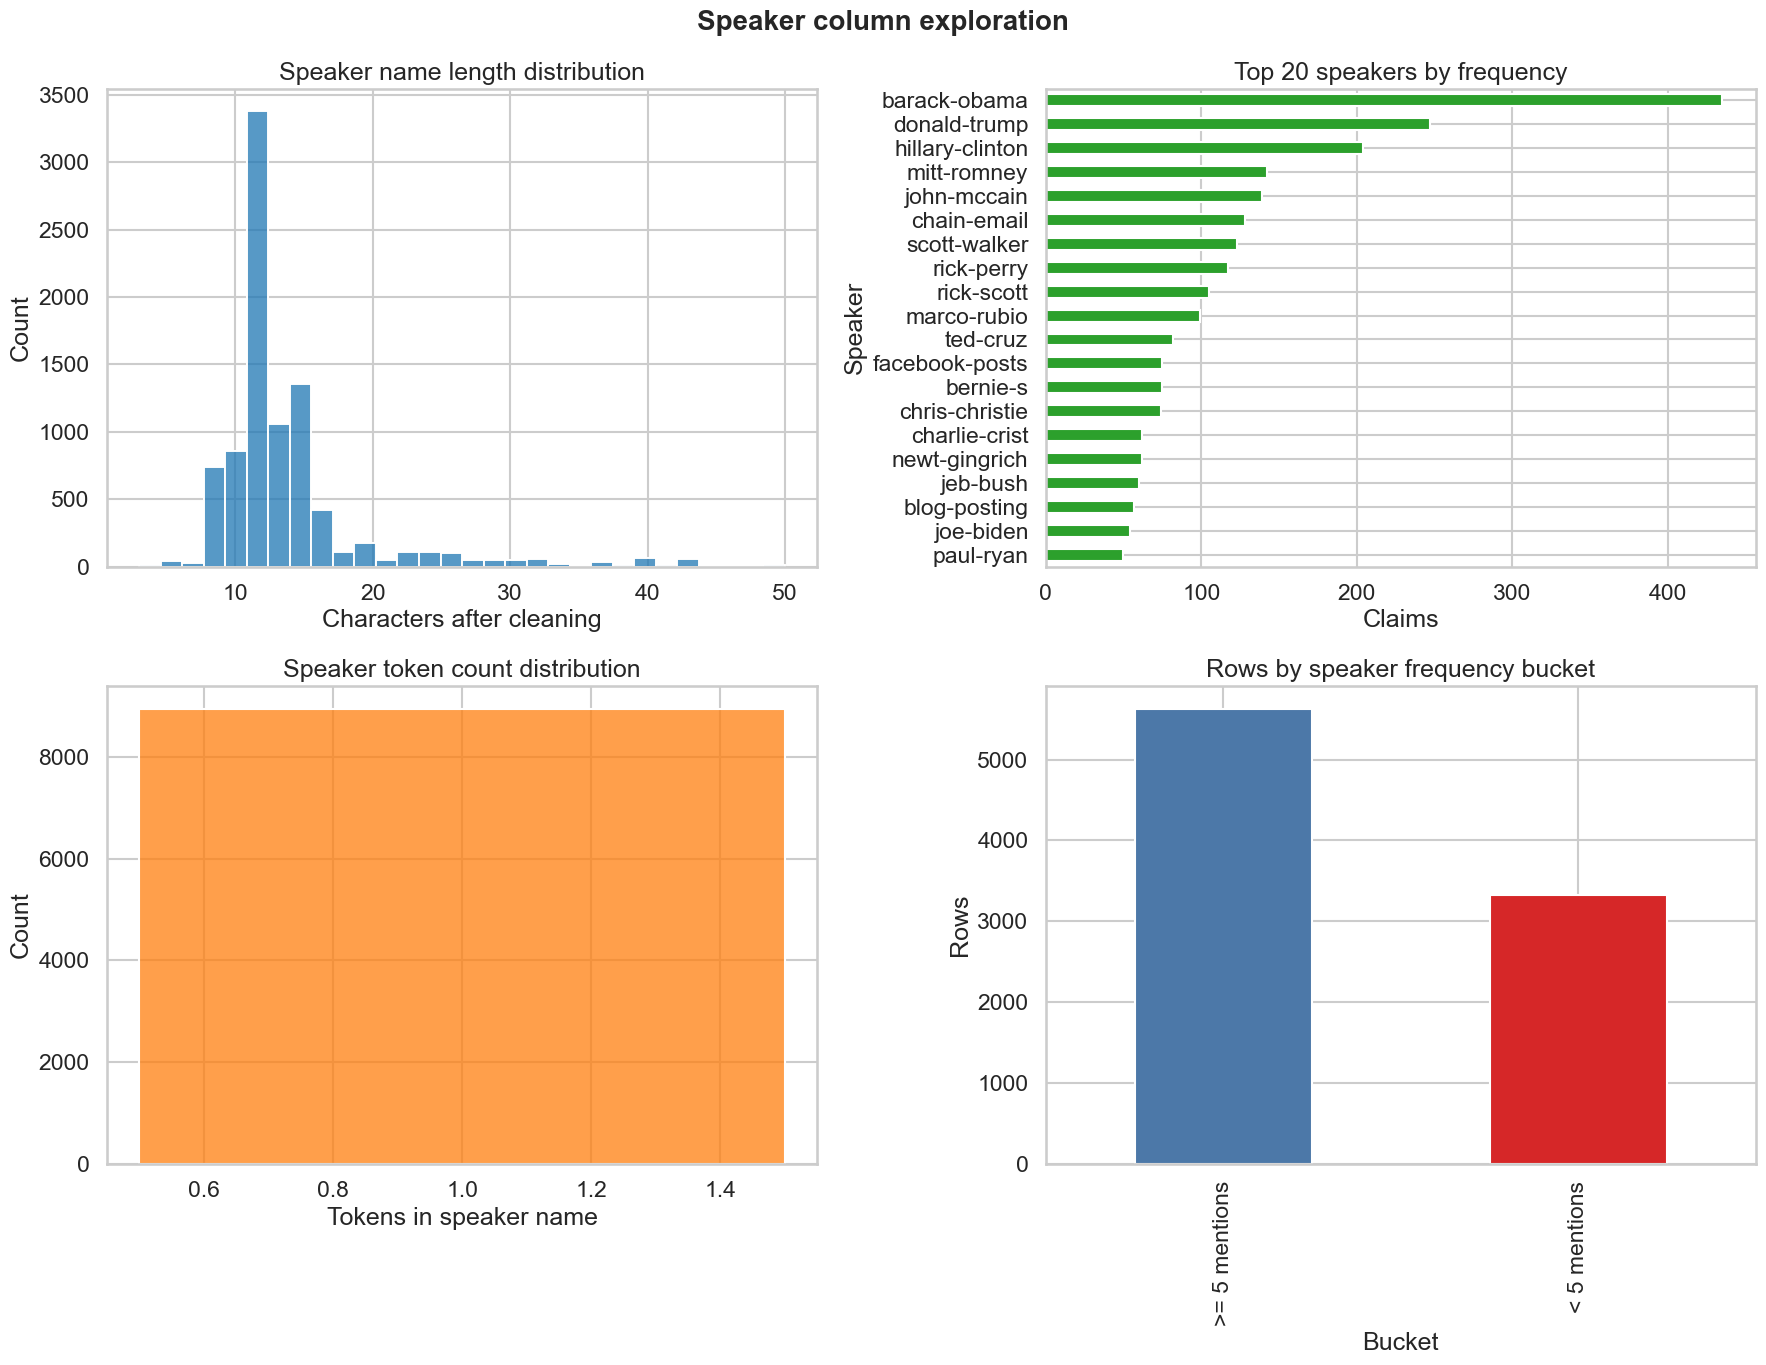

,claims,false_rate,true_rate
speaker,,,
barack-obama,435,53.6%,46.4%
donald-trump,247,83.4%,16.6%
hillary-clinton,204,48.0%,52.0%
mitt-romney,142,71.8%,28.2%
john-mccain,139,59.0%,41.0%
chain-email,128,96.9%,3.1%
scott-walker,123,65.0%,35.0%
rick-perry,117,71.8%,28.2%
rick-scott,105,64.8%,35.2%


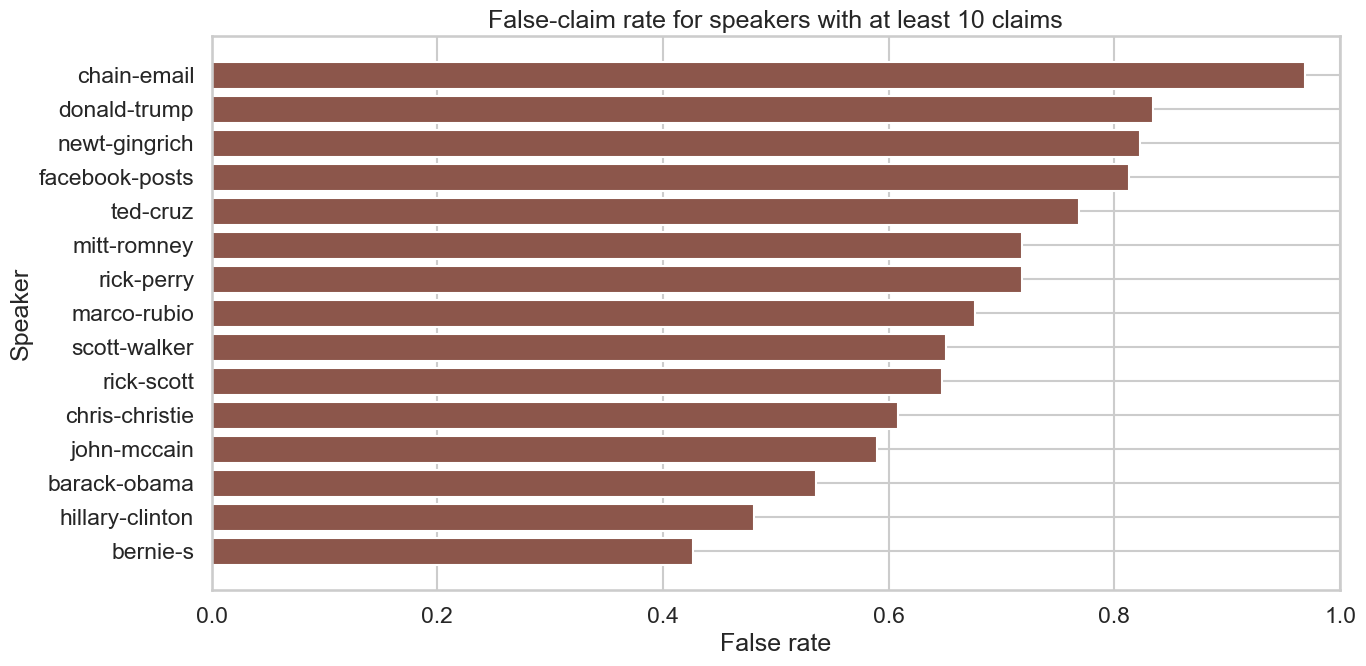

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

speaker_series = df['speaker'].fillna('').astype(str)
speaker_clean_local = (
    speaker_series.str.lower()
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)
speaker_clean_local = speaker_clean_local.replace('', 'unknown')
speaker_counts_local = speaker_clean_local.value_counts()
speaker_freq_local = speaker_clean_local.map(speaker_counts_local)
speaker_len_local = speaker_clean_local.str.len()
speaker_token_count_local = speaker_clean_local.str.split().str.len()
speaker_has_title_local = speaker_series.str.contains(r'\b(mr|mrs|ms|dr|gov|sen|rep|pres|prof)\b', case=False, regex=True).fillna(False)
speaker_has_comma_local = speaker_series.str.contains(',', regex=False).fillna(False)
speaker_has_period_local = speaker_series.str.contains('.', regex=False).fillna(False)

speaker_summary = pd.DataFrame({
    'metric': [
        'rows',
        'missing speaker values',
        'empty/blank speaker values',
        'unique cleaned speakers',
        'speakers occurring once',
        'speakers occurring 2-4 times',
        'speakers occurring 5+ times',
        'median speaker name length',
        'median speaker token count',
        'share with title/prefix',
        'share with comma',
    ],
    'value': [
        len(df),
        int(df['speaker'].isna().sum()),
        int((speaker_series.str.strip() == '').sum()),
        int(speaker_clean_local.nunique()),
        int((speaker_counts_local == 1).sum()),
        int(((speaker_counts_local >= 2) & (speaker_counts_local <= 4)).sum()),
        int((speaker_counts_local >= 5).sum()),
        float(speaker_len_local.median()),
        float(speaker_token_count_local.median()),
        float(speaker_has_title_local.mean() * 100),
        float(speaker_has_comma_local.mean() * 100),
    ]
})

print('Speaker preprocessing snapshot')
display(speaker_summary.style.format({'value': '{:,.2f}'}))

top_speakers = speaker_counts_local.head(20)
rare_threshold = 5
rare_share = (speaker_counts_local < rare_threshold).sum() / len(speaker_counts_local) * 100
row_share_rare = speaker_clean_local.isin(speaker_counts_local[speaker_counts_local < rare_threshold].index).mean() * 100

print(f'Unique cleaned speakers: {speaker_clean_local.nunique():,}')
print(f'Speakers appearing once: {(speaker_counts_local == 1).sum():,}')
print(f'Rows that belong to speakers with < {rare_threshold} mentions: {row_share_rare:.2f}%')
print(f'Share of unique speakers below {rare_threshold} mentions: {rare_share:.2f}%')

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Speaker column exploration', fontsize=20, fontweight='bold')

sns.histplot(speaker_len_local, bins=30, ax=axes[0, 0], color='#1f77b4')
axes[0, 0].set_title('Speaker name length distribution')
axes[0, 0].set_xlabel('Characters after cleaning')
axes[0, 0].set_ylabel('Count')

top_speakers.sort_values(ascending=True).plot(kind='barh', ax=axes[0, 1], color='#2ca02c')
axes[0, 1].set_title('Top 20 speakers by frequency')
axes[0, 1].set_xlabel('Claims')
axes[0, 1].set_ylabel('Speaker')

sns.histplot(speaker_token_count_local, bins=10, discrete=True, ax=axes[1, 0], color='#ff7f0e')
axes[1, 0].set_title('Speaker token count distribution')
axes[1, 0].set_xlabel('Tokens in speaker name')
axes[1, 0].set_ylabel('Count')

speaker_plot_df = pd.DataFrame({
    'speaker': speaker_clean_local,
    'frequency': speaker_freq_local,
})
speaker_plot_df['is_rare'] = speaker_plot_df['frequency'] < rare_threshold
rare_counts = speaker_plot_df['is_rare'].value_counts().reindex([False, True], fill_value=0)
rare_counts.index = ['>= 5 mentions', '< 5 mentions']
rare_counts.plot(kind='bar', ax=axes[1, 1], color=['#4c78a8', '#d62728'])
axes[1, 1].set_title('Rows by speaker frequency bucket')
axes[1, 1].set_xlabel('Bucket')
axes[1, 1].set_ylabel('Rows')

plt.tight_layout()
plt.show()

if 'label' in df.columns:
    label_series = df['label']
    if not pd.api.types.is_numeric_dtype(label_series):
        label_series = label_series.astype(str).str.lower().map({'true': 0, 'false': 1, '0': 0, '1': 1})
    speaker_label = (
        pd.DataFrame({'speaker': speaker_clean_local, 'label': label_series})
        .dropna(subset=['label'])
        .groupby('speaker')
        .agg(
            claims=('label', 'size'),
            false_rate=('label', 'mean'),
        )
        .sort_values(['claims', 'false_rate'], ascending=[False, False])
    )

    speaker_label = speaker_label[speaker_label['claims'] >= 10].head(15).copy()
    if not speaker_label.empty:
        speaker_label['true_rate'] = 1 - speaker_label['false_rate']
        display(speaker_label.style.format({'claims': '{:,.0f}', 'false_rate': '{:.1%}', 'true_rate': '{:.1%}'}))

        fig, ax1 = plt.subplots(figsize=(14, 7))
        speaker_label_sorted = speaker_label.sort_values('false_rate', ascending=True)
        ax1.barh(speaker_label_sorted.index, speaker_label_sorted['false_rate'], color='#8c564b')
        ax1.set_title('False-claim rate for speakers with at least 10 claims')
        ax1.set_xlabel('False rate')
        ax1.set_ylabel('Speaker')
        ax1.set_xlim(0, 1)
        plt.tight_layout()
        plt.show()



SPEAKER JOB: EXPLORATORY INSIGHTS & PREPROCESSING PLANNING

1. BASIC DATA QUALITY SUMMARY
----------------------------------------------------------------------
                               metric       value
                           Total rows 8950.000000
           Missing speaker_job values 2482.000000
       Empty/blank speaker_job values 2482.000000
                  Unique cleaned jobs 1018.000000
                  Jobs occurring once  610.000000
             Jobs occurring 2-4 times  251.000000
             Jobs occurring 5-9 times   74.000000
             Jobs occurring 10+ times   83.000000
      Median job title length (chars)   12.000000
               Median job token count    2.000000
               Share with "/" (slash)    0.212291
           Share with "&" (ampersand)    0.078212
               Share with "," (comma)    6.134078
Share with title/executive indicators   37.094972

Rarity threshold: < 5 occurrences
Unique jobs below threshold: 861 (84.58%)
Rows belongi

C:\Users\CmdrC\AppData\Local\Temp\ipykernel_23588\2322771844.py:34: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  speaker_job_has_title_case = speaker_job_raw.str.contains(


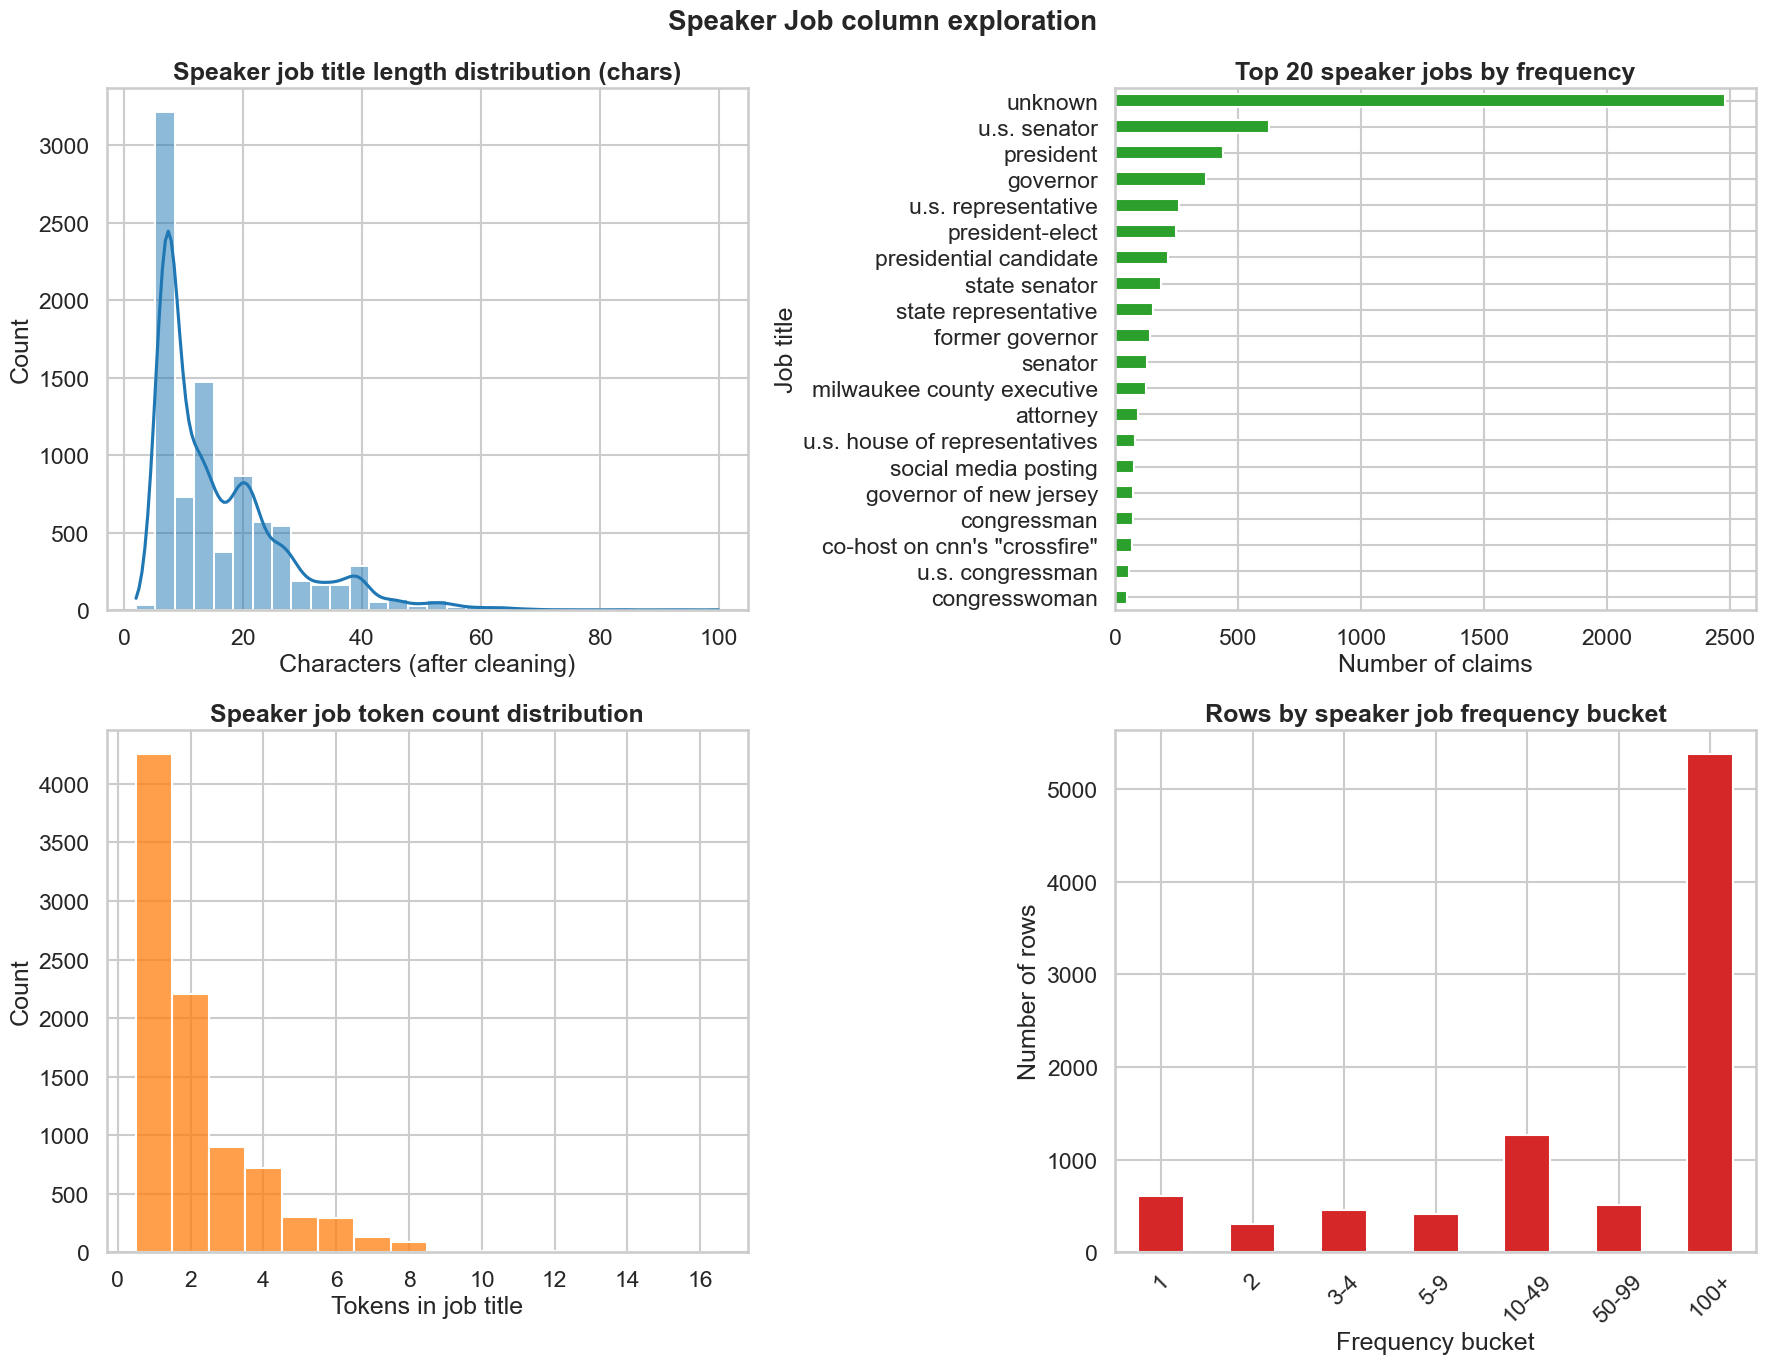

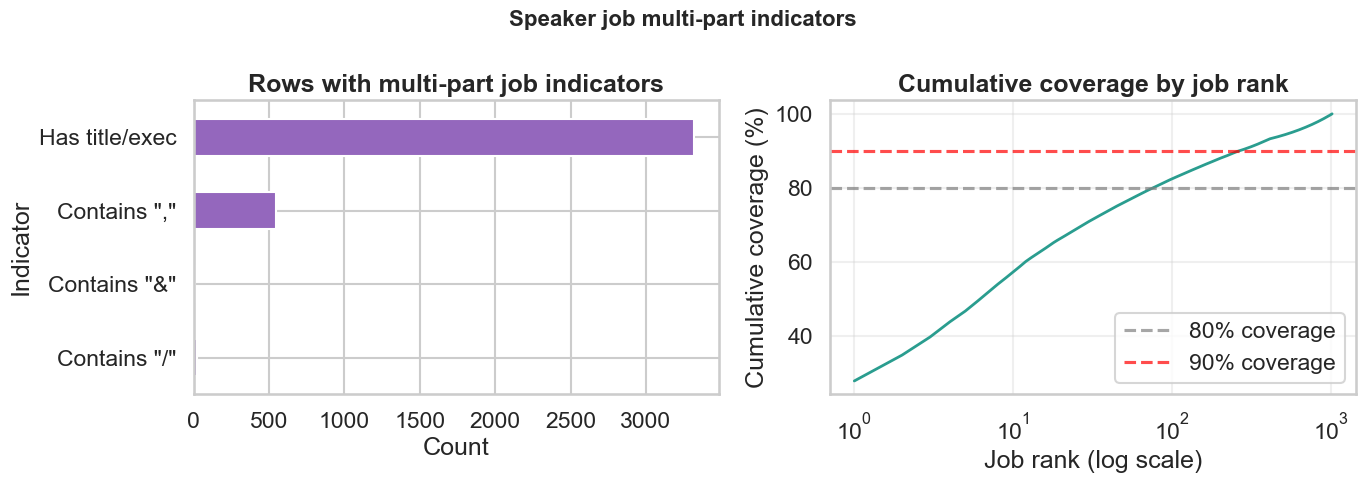


3. FALSE-CLAIM RATE BY SPEAKER JOB (Top 20 jobs, min 5 samples)
----------------------------------------------------------------------
                                         total_claims  true_claims  false_claims  false_rate
job                                                                                         
unknown                                          2482          751          1731        69.7
u.s. senator                                      627          283           344        54.9
president                                         438          203           235        53.7
governor                                          368          124           244        66.3
u.s. representative                               260           97           163        62.7
president-elect                                   247           41           206        83.4
presidential candidate                            216          109           107        49.5
state senator              

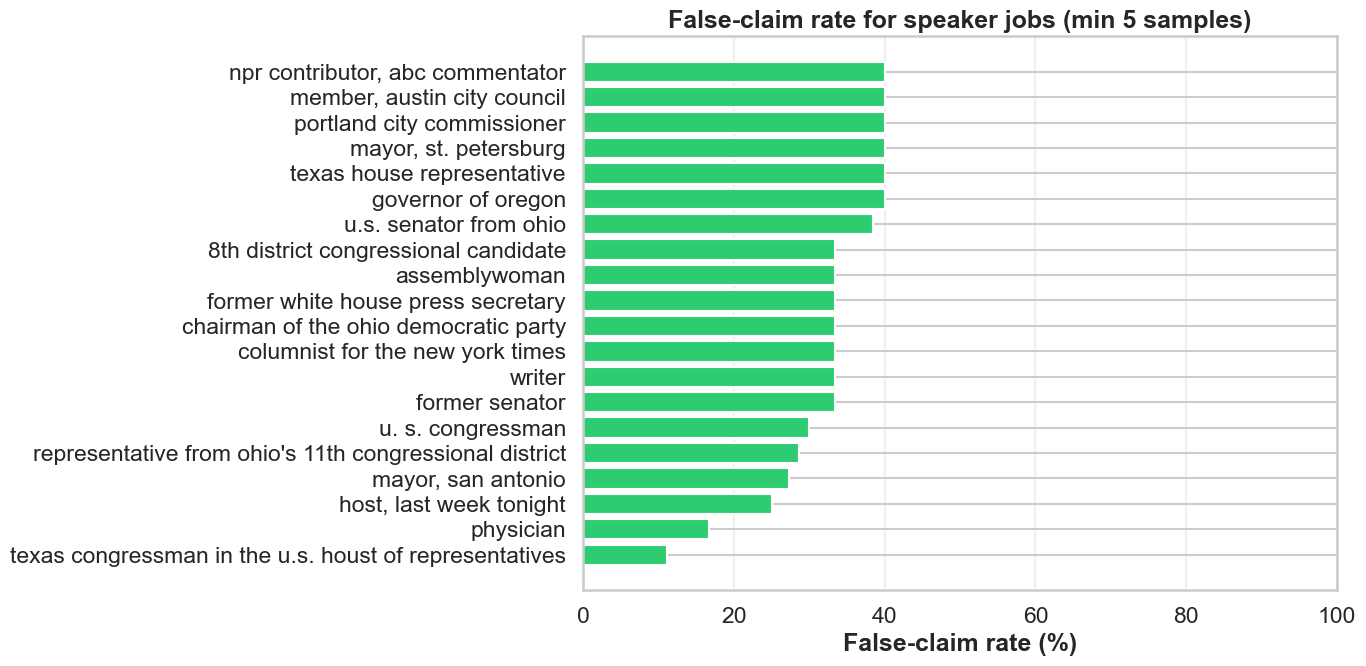


4. SAMPLE SPEAKER JOBS (First 10 unique)
----------------------------------------------------------------------
          speaker_job_raw         speaker_job_clean  frequency  length  token_count  has_slash  has_ampersand
          President-Elect           president-elect        247      15            1      False          False
             U.S. senator              u.s. senator        627      12            2      False          False
    Political commentator     political commentator         15      21            2      False          False
                                            unknown       2482       7            1      False          False
                President                 president        438       9            1      False          False
    Attorney, businessman     attorney, businessman          2      21            2      False          False
                 governor                  governor        368       8            1      False          False
       

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_theme(style="whitegrid", context="talk")

print("=" * 70)
print("SPEAKER JOB: EXPLORATORY INSIGHTS & PREPROCESSING PLANNING")
print("=" * 70)

# Extract and clean speaker_job column
speaker_job_raw = df['speaker_job'].fillna('').astype(str)

# Normalize: lowercase, trim, collapse whitespace
speaker_job_clean_local = (
    speaker_job_raw.str.lower()
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)
speaker_job_clean_local = speaker_job_clean_local.replace('', 'unknown')

# Frequency encoding
speaker_job_counts_local = speaker_job_clean_local.value_counts()
speaker_job_freq_local = speaker_job_clean_local.map(speaker_job_counts_local)

# Shape and pattern features
speaker_job_len_local = speaker_job_clean_local.str.len()
speaker_job_token_count_local = speaker_job_clean_local.str.split().str.len()
speaker_job_has_slash = speaker_job_raw.str.contains('/', regex=False).fillna(False)
speaker_job_has_ampersand = speaker_job_raw.str.contains('&', regex=False).fillna(False)
speaker_job_has_comma = speaker_job_raw.str.contains(',', regex=False).fillna(False)
speaker_job_has_title_case = speaker_job_raw.str.contains(
    r'\b(ceo|cfo|cto|professor|doctor|dr|senator|judge|mayor|governor|attorney|lawyer|president|executive|director)\b',
    case=False, regex=True
).fillna(False)

# Basic quality summary
print("\n1. BASIC DATA QUALITY SUMMARY")
print("-" * 70)
speaker_job_summary = pd.DataFrame({
    'metric': [
        'Total rows',
        'Missing speaker_job values',
        'Empty/blank speaker_job values',
        'Unique cleaned jobs',
        'Jobs occurring once',
        'Jobs occurring 2-4 times',
        'Jobs occurring 5-9 times',
        'Jobs occurring 10+ times',
        'Median job title length (chars)',
        'Median job token count',
        'Share with "/" (slash)',
        'Share with "&" (ampersand)',
        'Share with "," (comma)',
        'Share with title/executive indicators',
    ],
    'value': [
        len(df),
        int(df['speaker_job'].isna().sum()),
        int((speaker_job_raw.str.strip() == '').sum()),
        int(speaker_job_clean_local.nunique()),
        int((speaker_job_counts_local == 1).sum()),
        int(((speaker_job_counts_local >= 2) & (speaker_job_counts_local <= 4)).sum()),
        int(((speaker_job_counts_local >= 5) & (speaker_job_counts_local <= 9)).sum()),
        int((speaker_job_counts_local >= 10).sum()),
        float(speaker_job_len_local.median()),
        float(speaker_job_token_count_local.median()),
        float(speaker_job_has_slash.mean() * 100),
        float(speaker_job_has_ampersand.mean() * 100),
        float(speaker_job_has_comma.mean() * 100),
        float(speaker_job_has_title_case.mean() * 100),
    ]
})

print(speaker_job_summary.to_string(index=False))

# Rarity analysis
rare_threshold = 5
rare_jobs = speaker_job_counts_local[speaker_job_counts_local < rare_threshold].index
rare_share = (speaker_job_counts_local < rare_threshold).sum() / len(speaker_job_counts_local) * 100
row_share_rare = speaker_job_clean_local.isin(rare_jobs).mean() * 100

print(f"\nRarity threshold: < {rare_threshold} occurrences")
print(f"Unique jobs below threshold: {len(rare_jobs)} ({rare_share:.2f}%)")
print(f"Rows belonging to rare jobs: {row_share_rare:.2f}%")

# Top 20 jobs
print("\n2. TOP 20 SPEAKER JOBS BY FREQUENCY")
print("-" * 70)
top_jobs = speaker_job_counts_local.head(20)
print(top_jobs.to_string())

print(f"\nTop 20 jobs cover {top_jobs.sum() / len(speaker_job_clean_local) * 100:.2f}% of all rows")

# Visualization: Basic patterns
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Speaker Job column exploration', fontsize=20, fontweight='bold')

# Plot 1: Job title length distribution
sns.histplot(speaker_job_len_local, bins=30, ax=axes[0, 0], color='#1f77b4', kde=True)
axes[0, 0].set_title('Speaker job title length distribution (chars)', fontweight='bold')
axes[0, 0].set_xlabel('Characters (after cleaning)')
axes[0, 0].set_ylabel('Count')

# Plot 2: Top 20 jobs (horizontal bar chart)
top_jobs.sort_values(ascending=True).plot(kind='barh', ax=axes[0, 1], color='#2ca02c')
axes[0, 1].set_title('Top 20 speaker jobs by frequency', fontweight='bold')
axes[0, 1].set_xlabel('Number of claims')
axes[0, 1].set_ylabel('Job title')

# Plot 3: Token count distribution
sns.histplot(speaker_job_token_count_local, bins=15, discrete=True, ax=axes[1, 0], color='#ff7f0e')
axes[1, 0].set_title('Speaker job token count distribution', fontweight='bold')
axes[1, 0].set_xlabel('Tokens in job title')
axes[1, 0].set_ylabel('Count')

# Plot 4: Frequency buckets
job_freq_df = pd.DataFrame({
    'job': speaker_job_clean_local,
    'frequency': speaker_job_freq_local,
})
job_freq_df['freq_bucket'] = pd.cut(
    job_freq_df['frequency'],
    bins=[0, 1, 2, 5, 10, 50, 100, 10000],
    labels=['1', '2', '3-4', '5-9', '10-49', '50-99', '100+'],
    right=True
)
freq_bucket_counts = job_freq_df['freq_bucket'].value_counts().sort_index()
freq_bucket_counts.plot(kind='bar', ax=axes[1, 1], color='#d62728')
axes[1, 1].set_title('Rows by speaker job frequency bucket', fontweight='bold')
axes[1, 1].set_xlabel('Frequency bucket')
axes[1, 1].set_ylabel('Number of rows')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Visualization: Multi-part job indicators
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Speaker job multi-part indicators', fontsize=16, fontweight='bold')

# Plot 1: Multi-part indicators breakdown
indicators_data = pd.DataFrame({
    'Contains "/"': [speaker_job_has_slash.sum()],
    'Contains "&"': [speaker_job_has_ampersand.sum()],
    'Contains ","': [speaker_job_has_comma.sum()],
    'Has title/exec': [speaker_job_has_title_case.sum()],
})
indicators_data.T.plot(kind='barh', ax=axes[0], color='#9467bd', legend=False)
axes[0].set_title('Rows with multi-part job indicators', fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Indicator')

# Plot 2: Cumulative coverage by job rank
job_cum = speaker_job_counts_local.cumsum() / len(speaker_job_clean_local) * 100
axes[1].plot(range(1, len(job_cum)+1), job_cum.values, color='#2a9d8f', linewidth=2)
axes[1].axhline(80, color='gray', linestyle='--', alpha=0.7, label='80% coverage')
axes[1].axhline(90, color='red', linestyle='--', alpha=0.7, label='90% coverage')
axes[1].set_xscale('log')
axes[1].set_xlabel('Job rank (log scale)')
axes[1].set_ylabel('Cumulative coverage (%)')
axes[1].set_title('Cumulative coverage by job rank', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Label analysis by speaker job (if label exists)
if 'label' in df.columns:
    print("\n3. FALSE-CLAIM RATE BY SPEAKER JOB (Top 20 jobs, min 5 samples)")
    print("-" * 70)
    
    label_series = df['label'].copy()
    if not pd.api.types.is_numeric_dtype(label_series):
        label_series = label_series.astype(str).str.lower().map({'true': 0, 'false': 1, '0': 0, '1': 1})
    
    job_label_stats = (
        pd.DataFrame({'job': speaker_job_clean_local, 'label': label_series})
        .dropna(subset=['label'])
        .groupby('job')
        .agg(
            total_claims=('label', 'size'),
            false_claims=('label', 'sum'),
            false_rate=('label', 'mean'),
        )
        .sort_values('total_claims', ascending=False)
    )
    
    # Filter to jobs with at least 5 samples
    job_label_stats_filtered = job_label_stats[job_label_stats['total_claims'] >= 5].head(20).copy()
    job_label_stats_filtered['true_claims'] = job_label_stats_filtered['total_claims'] - job_label_stats_filtered['false_claims']
    job_label_stats_filtered = job_label_stats_filtered[['total_claims', 'true_claims', 'false_claims', 'false_rate']]
    job_label_stats_filtered['false_rate'] = (job_label_stats_filtered['false_rate'] * 100).round(1)
    
    print(job_label_stats_filtered.to_string())
    
    # Visualization: False-claim rate by top jobs
    if not job_label_stats_filtered.empty:
        fig, ax = plt.subplots(figsize=(14, 7))
        job_label_sorted = job_label_stats[job_label_stats['total_claims'] >= 5].sort_values('false_rate', ascending=True).head(20)
        colors = ['#2ecc71' if x < 0.5 else '#e74c3c' for x in job_label_sorted['false_rate']]
        ax.barh(range(len(job_label_sorted)), job_label_sorted['false_rate'] * 100, color=colors)
        ax.set_yticks(range(len(job_label_sorted)))
        ax.set_yticklabels(job_label_sorted.index)
        ax.set_xlabel('False-claim rate (%)', fontweight='bold')
        ax.set_title('False-claim rate for speaker jobs (min 5 samples)', fontweight='bold')
        ax.set_xlim(0, 100)
        ax.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.show()

# Sample inspection
print("\n4. SAMPLE SPEAKER JOBS (First 10 unique)")
print("-" * 70)
sample_jobs = pd.DataFrame({
    'speaker_job_raw': speaker_job_raw,
    'speaker_job_clean': speaker_job_clean_local,
    'frequency': speaker_job_freq_local,
    'length': speaker_job_len_local,
    'token_count': speaker_job_token_count_local,
    'has_slash': speaker_job_has_slash,
    'has_ampersand': speaker_job_has_ampersand,
}).drop_duplicates(subset=['speaker_job_clean']).head(10)

print(sample_jobs.to_string(index=False))

print("\n5. PREPROCESSING RECOMMENDATIONS")
print("-" * 70)
recommendations = [
    "✓ Normalize to lowercase and trim whitespace (done above).",
    "✓ Replace empty values with 'unknown' for explicit handling.",
    "• Group rare jobs (< 5 occurrences) into 'other' category.",
    "• Create frequency encoding: speaker_job_frequency (count of occurrences).",
    "• Create is_rare flag: 1 if job occurs < 5 times, else 0.",
    "• Create job length and token count features for style patterns.",
    "• Detect multi-part jobs: has_slash, has_ampersand, has_comma indicators.",
    "• Extract title/executive keywords: ceo, cfo, doctor, senator, judge, etc.",
    "• Consider broad occupation buckets:",
    "    - Politics: senator, representative, governor, mayor, etc.",
    "    - Law: attorney, judge, lawyer, prosecutor, etc.",
    "    - Media: journalist, editor, broadcaster, etc.",
    "    - Business: ceo, cfo, executive, manager, etc.",
    "    - Education: professor, teacher, administrator, etc.",
    "    - Healthcare: doctor, physician, nurse, etc.",
    "    - Public service: official, officer, staff, etc.",
    "• Consider one-hot encoding for top 10-15 most frequent jobs.",
    "• Use frequency encoding or target encoding for remaining jobs.",
    "• **Leakage warning:** Compute job-level false-rate stats ONLY within CV folds.",
]

for rec in recommendations:
    print(rec)

PARTY AFFILIATION: EXPLORATORY INSIGHTS & PREPROCESSING PLANNING

1. BASIC DATA QUALITY SUMMARY
----------------------------------------------------------------------
                                 metric  value
                             Total rows 8950.0
       Missing party_affiliation values    0.0
   Empty/blank party_affiliation values    0.0
                 Unique cleaned parties   24.0
                 Parties occurring once    6.0
            Parties occurring 2-4 times    3.0
            Parties occurring 5-9 times    3.0
            Parties occurring 10+ times   12.0
Median party affiliation length (chars)    9.0
               Median party token count    1.0
                 Share with "/" (slash)    0.0
             Share with "&" (ampersand)    0.0
                 Share with "," (comma)    0.0
                 Share with parentheses    0.0

Rarity threshold: < 5 occurrences
Unique parties below threshold: 9 (37.50%)
Rows belonging to rare parties: 0.15%

2. TOP 20 P

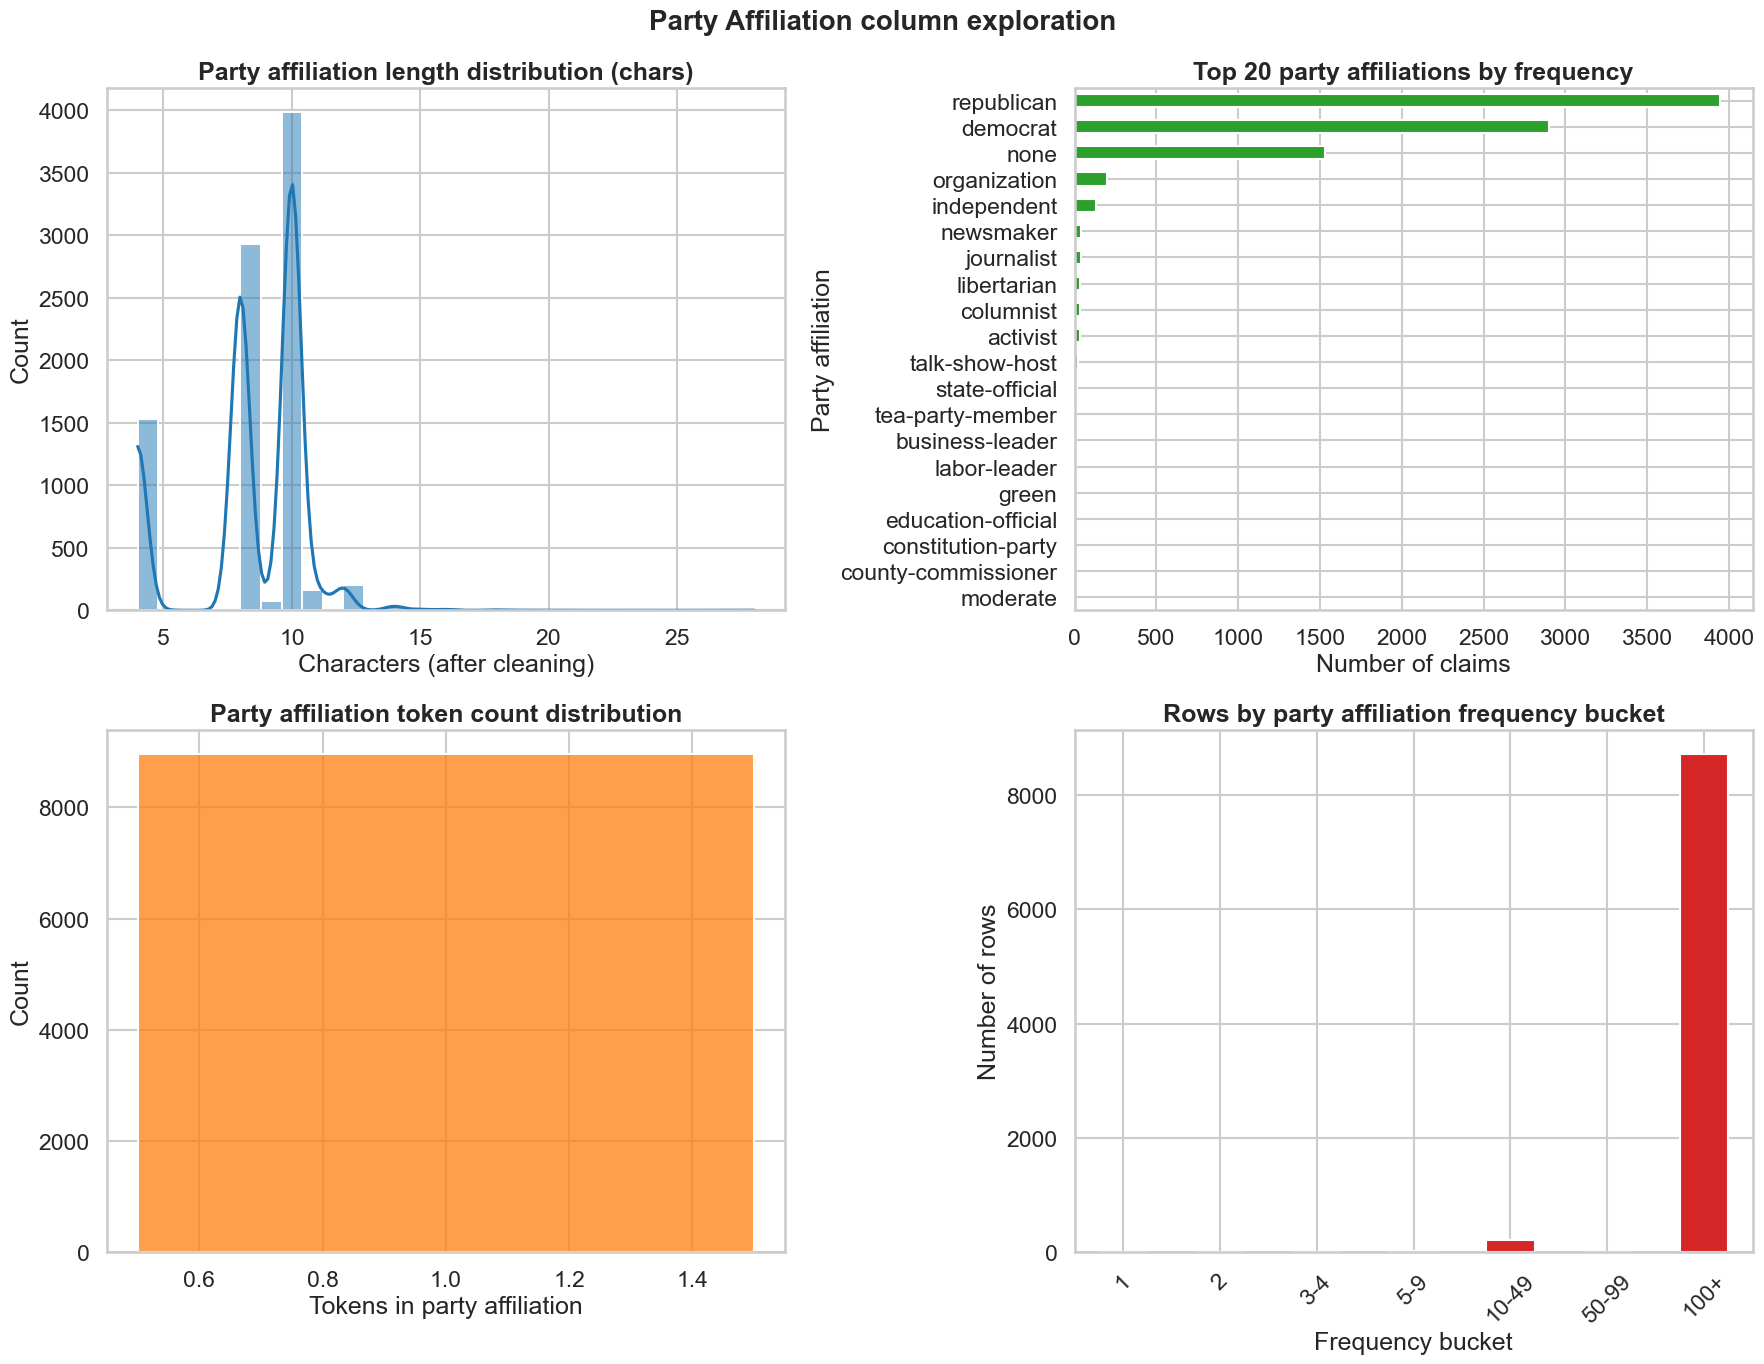

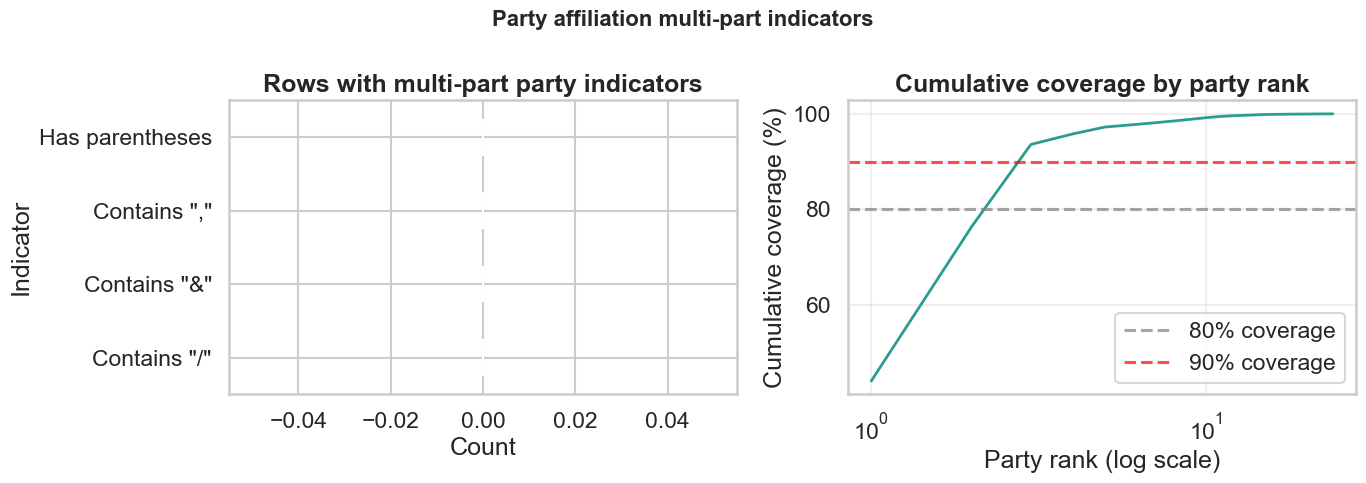


3. FALSE-CLAIM RATE BY PARTY AFFILIATION (Top 20 parties, min 5 samples)
----------------------------------------------------------------------
                  total_claims  true_claims  false_claims  false_rate
party                                                                
republican                3947         1203          2744        69.5
democrat                  2898         1269          1629        56.2
none                      1531          469          1062        69.4
organization               197           37           160        81.2
independent                130           72            58        44.6
newsmaker                   41           19            22        53.7
journalist                  37           18            19        51.4
libertarian                 34           13            21        61.8
columnist                   32           13            19        59.4
activist                    30           13            17        56.7
talk-show-host 

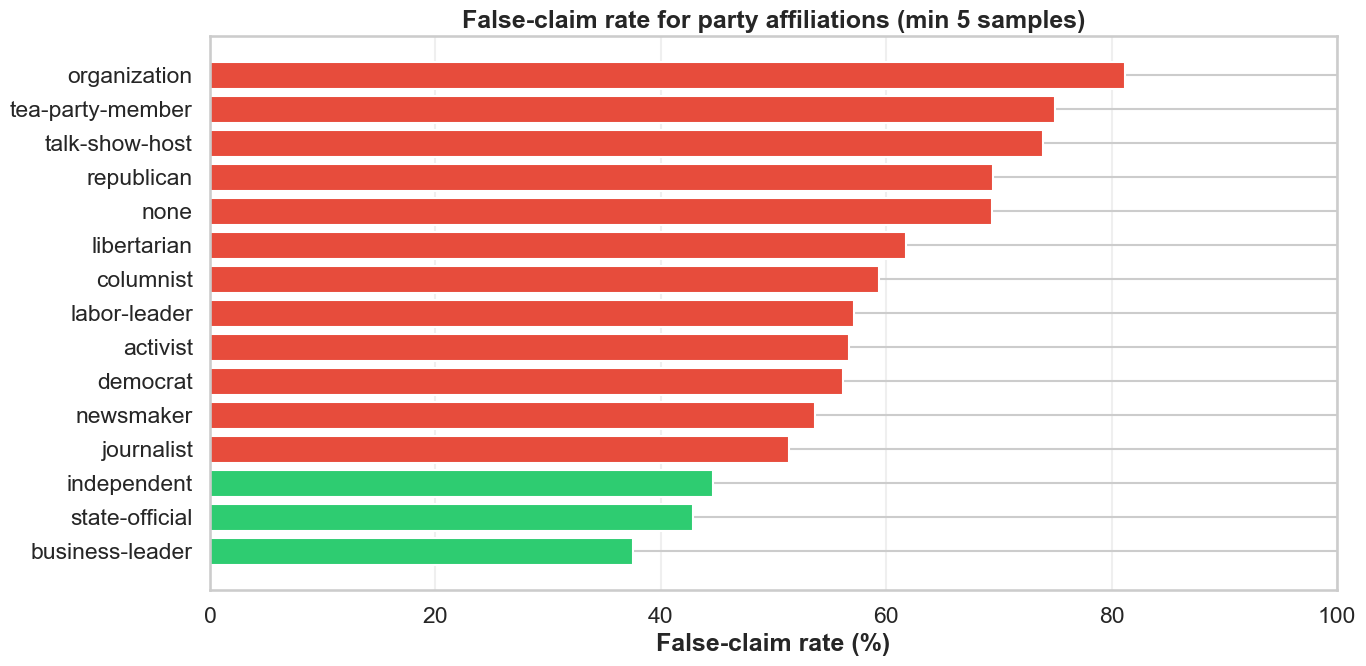


4. SAMPLE PARTY AFFILIATIONS (First 10 unique)
----------------------------------------------------------------------
party_affiliation_raw party_affiliation_clean  frequency  length  token_count  has_slash  has_ampersand  has_parentheses
           republican              republican       3947      10            1      False          False            False
             democrat                democrat       2898       8            1      False          False            False
                 none                    none       1531       4            1      False          False            False
          independent             independent        130      11            1      False          False            False
           journalist              journalist         37      10            1      False          False            False
         organization            organization        197      12            1      False          False            False
       talk-show-host          tal

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_theme(style="whitegrid", context="talk")

print("=" * 70)
print("PARTY AFFILIATION: EXPLORATORY INSIGHTS & PREPROCESSING PLANNING")
print("=" * 70)

# Extract and clean party_affiliation column
party_affiliation_raw = df['party_affiliation'].fillna('').astype(str)

# Normalize: lowercase, trim, collapse whitespace
party_affiliation_clean_local = (
    party_affiliation_raw.str.lower()
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)
party_affiliation_clean_local = party_affiliation_clean_local.replace('', 'unknown')

# Frequency encoding
party_affiliation_counts_local = party_affiliation_clean_local.value_counts()
party_affiliation_freq_local = party_affiliation_clean_local.map(party_affiliation_counts_local)

# Shape and pattern features
party_affiliation_len_local = party_affiliation_clean_local.str.len()
party_affiliation_token_count_local = party_affiliation_clean_local.str.split().str.len()
party_affiliation_has_slash = party_affiliation_raw.str.contains('/', regex=False).fillna(False)
party_affiliation_has_ampersand = party_affiliation_raw.str.contains('&', regex=False).fillna(False)
party_affiliation_has_comma = party_affiliation_raw.str.contains(',', regex=False).fillna(False)
party_affiliation_has_parentheses = party_affiliation_raw.str.contains(r'[\(\)]', regex=True).fillna(False)

# Basic quality summary
print("\n1. BASIC DATA QUALITY SUMMARY")
print("-" * 70)
party_affiliation_summary = pd.DataFrame({
    'metric': [
        'Total rows',
        'Missing party_affiliation values',
        'Empty/blank party_affiliation values',
        'Unique cleaned parties',
        'Parties occurring once',
        'Parties occurring 2-4 times',
        'Parties occurring 5-9 times',
        'Parties occurring 10+ times',
        'Median party affiliation length (chars)',
        'Median party token count',
        'Share with "/" (slash)',
        'Share with "&" (ampersand)',
        'Share with "," (comma)',
        'Share with parentheses',
    ],
    'value': [
        len(df),
        int(df['party_affiliation'].isna().sum()),
        int((party_affiliation_raw.str.strip() == '').sum()),
        int(party_affiliation_clean_local.nunique()),
        int((party_affiliation_counts_local == 1).sum()),
        int(((party_affiliation_counts_local >= 2) & (party_affiliation_counts_local <= 4)).sum()),
        int(((party_affiliation_counts_local >= 5) & (party_affiliation_counts_local <= 9)).sum()),
        int((party_affiliation_counts_local >= 10).sum()),
        float(party_affiliation_len_local.median()),
        float(party_affiliation_token_count_local.median()),
        float(party_affiliation_has_slash.mean() * 100),
        float(party_affiliation_has_ampersand.mean() * 100),
        float(party_affiliation_has_comma.mean() * 100),
        float(party_affiliation_has_parentheses.mean() * 100),
    ]
})

print(party_affiliation_summary.to_string(index=False))

# Rarity analysis
rare_threshold = 5
rare_parties = party_affiliation_counts_local[party_affiliation_counts_local < rare_threshold].index
rare_share = (party_affiliation_counts_local < rare_threshold).sum() / len(party_affiliation_counts_local) * 100
row_share_rare = party_affiliation_clean_local.isin(rare_parties).mean() * 100

print(f"\nRarity threshold: < {rare_threshold} occurrences")
print(f"Unique parties below threshold: {len(rare_parties)} ({rare_share:.2f}%)")
print(f"Rows belonging to rare parties: {row_share_rare:.2f}%")

# Top 20 parties
print("\n2. TOP 20 PARTY AFFILIATIONS BY FREQUENCY")
print("-" * 70)
top_parties = party_affiliation_counts_local.head(20)
print(top_parties.to_string())

print(f"\nTop 20 parties cover {top_parties.sum() / len(party_affiliation_clean_local) * 100:.2f}% of all rows")

# Visualization: Basic patterns
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Party Affiliation column exploration', fontsize=20, fontweight='bold')

# Plot 1: Party affiliation length distribution
sns.histplot(party_affiliation_len_local, bins=30, ax=axes[0, 0], color='#1f77b4', kde=True)
axes[0, 0].set_title('Party affiliation length distribution (chars)', fontweight='bold')
axes[0, 0].set_xlabel('Characters (after cleaning)')
axes[0, 0].set_ylabel('Count')

# Plot 2: Top 20 parties (horizontal bar chart)
top_parties.sort_values(ascending=True).plot(kind='barh', ax=axes[0, 1], color='#2ca02c')
axes[0, 1].set_title('Top 20 party affiliations by frequency', fontweight='bold')
axes[0, 1].set_xlabel('Number of claims')
axes[0, 1].set_ylabel('Party affiliation')

# Plot 3: Token count distribution
sns.histplot(party_affiliation_token_count_local, bins=15, discrete=True, ax=axes[1, 0], color='#ff7f0e')
axes[1, 0].set_title('Party affiliation token count distribution', fontweight='bold')
axes[1, 0].set_xlabel('Tokens in party affiliation')
axes[1, 0].set_ylabel('Count')

# Plot 4: Frequency buckets
party_freq_df = pd.DataFrame({
    'party': party_affiliation_clean_local,
    'frequency': party_affiliation_freq_local,
})
party_freq_df['freq_bucket'] = pd.cut(
    party_freq_df['frequency'],
    bins=[0, 1, 2, 5, 10, 50, 100, 10000],
    labels=['1', '2', '3-4', '5-9', '10-49', '50-99', '100+'],
    right=True
)
freq_bucket_counts = party_freq_df['freq_bucket'].value_counts().sort_index()
freq_bucket_counts.plot(kind='bar', ax=axes[1, 1], color='#d62728')
axes[1, 1].set_title('Rows by party affiliation frequency bucket', fontweight='bold')
axes[1, 1].set_xlabel('Frequency bucket')
axes[1, 1].set_ylabel('Number of rows')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Visualization: Multi-part party indicators
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Party affiliation multi-part indicators', fontsize=16, fontweight='bold')

# Plot 1: Multi-part indicators breakdown
indicators_data = pd.DataFrame({
    'Contains "/"': [party_affiliation_has_slash.sum()],
    'Contains "&"': [party_affiliation_has_ampersand.sum()],
    'Contains ","': [party_affiliation_has_comma.sum()],
    'Has parentheses': [party_affiliation_has_parentheses.sum()],
})
indicators_data.T.plot(kind='barh', ax=axes[0], color='#9467bd', legend=False)
axes[0].set_title('Rows with multi-part party indicators', fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Indicator')

# Plot 2: Cumulative coverage by party rank
party_cum = party_affiliation_counts_local.cumsum() / len(party_affiliation_clean_local) * 100
axes[1].plot(range(1, len(party_cum)+1), party_cum.values, color='#2a9d8f', linewidth=2)
axes[1].axhline(80, color='gray', linestyle='--', alpha=0.7, label='80% coverage')
axes[1].axhline(90, color='red', linestyle='--', alpha=0.7, label='90% coverage')
axes[1].set_xscale('log')
axes[1].set_xlabel('Party rank (log scale)')
axes[1].set_ylabel('Cumulative coverage (%)')
axes[1].set_title('Cumulative coverage by party rank', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Label analysis by party affiliation (if label exists)
if 'label' in df.columns:
    print("\n3. FALSE-CLAIM RATE BY PARTY AFFILIATION (Top 20 parties, min 5 samples)")
    print("-" * 70)
    
    label_series = df['label'].copy()
    if not pd.api.types.is_numeric_dtype(label_series):
        label_series = label_series.astype(str).str.lower().map({'true': 0, 'false': 1, '0': 0, '1': 1})
    
    party_label_stats = (
        pd.DataFrame({'party': party_affiliation_clean_local, 'label': label_series})
        .dropna(subset=['label'])
        .groupby('party')
        .agg(
            total_claims=('label', 'size'),
            false_claims=('label', 'sum'),
            false_rate=('label', 'mean'),
        )
        .sort_values('total_claims', ascending=False)
    )
    
    # Filter to parties with at least 5 samples
    party_label_stats_filtered = party_label_stats[party_label_stats['total_claims'] >= 5].head(20).copy()
    party_label_stats_filtered['true_claims'] = party_label_stats_filtered['total_claims'] - party_label_stats_filtered['false_claims']
    party_label_stats_filtered = party_label_stats_filtered[['total_claims', 'true_claims', 'false_claims', 'false_rate']]
    party_label_stats_filtered['false_rate'] = (party_label_stats_filtered['false_rate'] * 100).round(1)
    
    print(party_label_stats_filtered.to_string())
    
    # Visualization: False-claim rate by top parties
    if not party_label_stats_filtered.empty:
        fig, ax = plt.subplots(figsize=(14, 7))
        party_label_sorted = party_label_stats[party_label_stats['total_claims'] >= 5].sort_values('false_rate', ascending=True).head(20)
        colors = ['#2ecc71' if x < 0.5 else '#e74c3c' for x in party_label_sorted['false_rate']]
        ax.barh(range(len(party_label_sorted)), party_label_sorted['false_rate'] * 100, color=colors)
        ax.set_yticks(range(len(party_label_sorted)))
        ax.set_yticklabels(party_label_sorted.index)
        ax.set_xlabel('False-claim rate (%)', fontweight='bold')
        ax.set_title('False-claim rate for party affiliations (min 5 samples)', fontweight='bold')
        ax.set_xlim(0, 100)
        ax.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.show()

# Sample inspection
print("\n4. SAMPLE PARTY AFFILIATIONS (First 10 unique)")
print("-" * 70)
sample_parties = pd.DataFrame({
    'party_affiliation_raw': party_affiliation_raw,
    'party_affiliation_clean': party_affiliation_clean_local,
    'frequency': party_affiliation_freq_local,
    'length': party_affiliation_len_local,
    'token_count': party_affiliation_token_count_local,
    'has_slash': party_affiliation_has_slash,
    'has_ampersand': party_affiliation_has_ampersand,
    'has_parentheses': party_affiliation_has_parentheses,
}).drop_duplicates(subset=['party_affiliation_clean']).head(10)

print(sample_parties.to_string(index=False))

print("\n5. PREPROCESSING RECOMMENDATIONS")
print("-" * 70)
recommendations = [
    "✓ Normalize to lowercase and trim whitespace (done above).",
    "✓ Replace empty values with 'unknown' for explicit handling.",
    "• Group rare parties (< 5 occurrences) into 'other' category.",
    "• Create frequency encoding: party_affiliation_frequency (count of occurrences).",
    "• Create is_rare flag: 1 if party occurs < 5 times, else 0.",
    "• Create party length and token count features for style patterns.",
    "• Detect multi-part parties: has_slash, has_ampersand, has_comma indicators.",
    "• Extract parenthetical information (e.g., independent (no party affiliation)).",
    "• Consider broad party categories:",
    "    - Democratic-affiliated",
    "    - Republican-affiliated",
    "    - Independent-affiliated",
    "    - Minor parties",
    "    - Unknown/no affiliation",
    "• Consider one-hot encoding for top 10-15 most frequent parties.",
    "• Use frequency encoding or target encoding for remaining parties.",
    "• **Leakage warning:** Compute party-level false-rate stats ONLY within CV folds.",
]

for rec in recommendations:
    print(rec)
